In [1]:
"""
FoodKadeh KPI Data Simulation
Generates synthetic buyers, suppliers, orders, marketing spend.
Then computes: Revenue, Gross Margin, AOV, CAC, LTV, LTV/CAC,
Retention Rate, Churn Rate, Repeat Purchase Rate,
Time to Second Order, CAC by Channel, Upsell/Cross-sell Rate,
plus NEW: Supplier Concentration (HHI), Buyer Concentration,
Buyer Segment Revenue Mix, and Retention Cohort Curves.
"""

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ---------- VISUAL STYLE ----------
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "primary": "#2E5266",
    "accent": "#F2A541",
    "good": "#3FA796",
    "bad": "#D65A5A",
    "neutral": "#B8B8B8",
    "highlight": "#6C5B7B",
}
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})

def fmt_money(x, pos):
    return f"${x:,.0f}"

def annotate_bars(ax, fmt="{:.0f}", pad=3, fontsize=9):
    for p in ax.patches:
        h = p.get_height()
        if pd.isna(h):
            continue
        ax.annotate(fmt.format(h), (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=fontsize, color="#333333",
                    xytext=(0, pad), textcoords="offset points")


Question: What kind of business scenario are we simulating for FoodKadeh?

This section generates a synthetic dataset representing FoodKadeh's B2B marketplace activity: buyer accounts (supermarkets, restaurants, cafes, hotels), supplier accounts, and the orders placed between them over a 6-month window (Jan–Jun 2026).

Each buyer is assigned a signup date, an acquisition channel (organic, paid ads, sales-led, or referral), and a buyer type. Each supplier carries a cost-of-goods ratio used later to compute margin. Orders are generated per buyer based on a simulated retention pattern — about 55% of buyers are "retained" and place many more orders than the rest, with order timing spaced out using a random gap model and order size (SKU count, GMV) drawn from set distributions. A small share of orders come back as cancelled rather than completed.

The goal is to simulate a realistic B2B marketplace funnel, not a random table of numbers. It's structured to answer the questions FoodKadeh actually needs answered: Which acquisition channels bring in buyers cheaply? Which buyers keep ordering versus go dormant? How does order size grow as a buyer matures (upsell effect)? How long does it take a new buyer to place a second order? This is what makes the downstream KPI section (CAC, LTV, retention, repeat purchase rate, time-to-second-order, upsell rate) meaningful, even though the underlying numbers are synthetic and not real FoodKadeh activity.

In [2]:
np.random.seed(42)

# fixed params controlling sim size, date range, channels, spend, buyer types
# ---------- CONFIG ----------
N_BUYERS = 400
N_SUPPLIERS = 30
START_DATE = datetime(2026, 1, 1)
END_DATE = datetime(2026, 6, 30)  # 6-month window, matches real FoodKadeh data period
CHANNELS = ["organic", "paid_ads", "sales_led", "referral"]
CHANNEL_SPEND = {"organic": 2000, "paid_ads": 45000, "sales_led": 60000, "referral": 5000}
BUYER_TYPES = ["supermarket", "restaurant", "cafe", "hotel"]

# generate buyer records: id, signup date, acquisition channel, buyer type
# ---------- BUYERS ----------
buyer_ids = [f"B{i:04d}" for i in range(N_BUYERS)]
signup_dates = [START_DATE + timedelta(days=np.random.randint(0, 130)) for _ in buyer_ids]  # leaves room to order before END_DATE
channels = np.random.choice(CHANNELS, N_BUYERS, p=[0.35, 0.25, 0.25, 0.15])
buyer_types = np.random.choice(BUYER_TYPES, N_BUYERS, p=[0.3, 0.4, 0.2, 0.1])

buyers = pd.DataFrame({
    "buyer_id": buyer_ids,
    "signup_date": signup_dates,
    "channel": channels,
    "buyer_type": buyer_types,
})

# buyers acquired per channel -> used for CAC by channel
buyers_per_channel = buyers["channel"].value_counts().to_dict()

# generate supplier records with random cost-of-goods ratio per supplier
# ---------- SUPPLIERS ----------
supplier_ids = [f"S{i:03d}" for i in range(N_SUPPLIERS)]
suppliers = pd.DataFrame({
    "supplier_id": supplier_ids,
    "cogs_ratio": np.random.uniform(0.55, 0.75, N_SUPPLIERS),  # cost of goods as % of price
})

# ---------- ORDERS ----------
orders = []
order_id = 0
for _, b in buyers.iterrows():
    # active window: from signup to end date
    days_active = (END_DATE - b["signup_date"]).days
    if days_active <= 0:
        continue
    # buyer "engagement" level drives order frequency (some churn early)
    is_retained = np.random.rand() < 0.55  # ~55% retained buyers
    n_orders = np.random.poisson(8 if is_retained else 1.5)
    n_orders = max(n_orders, 1) if np.random.rand() < 0.97 else 0  # 3% never order (signup only)

    order_gap_days = sorted(np.random.exponential(scale=25, size=n_orders).cumsum())
    for i, gap in enumerate(order_gap_days):
        order_date = b["signup_date"] + timedelta(days=int(gap))
        if order_date > END_DATE:
            continue
        supplier = np.random.choice(supplier_ids)
        # upsell effect: SKU count grows slightly with order sequence (i)
        base_skus = np.random.poisson(4)
        n_skus = max(1, base_skus + int(i * 0.3))
        unit_price = np.random.uniform(15, 60)
        gmv = round(unit_price * n_skus * np.random.uniform(0.9, 1.1), 2)
        status = np.random.choice(["completed", "cancelled"], p=[0.93, 0.07])
        orders.append({
            "order_id": order_id,
            "buyer_id": b["buyer_id"],
            "supplier_id": supplier,
            "order_date": order_date,
            "order_seq": i + 1,
            "n_skus": n_skus,
            "gmv": gmv,
            "status": status,
        })
        order_id += 1

orders = pd.DataFrame(orders)
orders = orders.merge(suppliers, on="supplier_id")
orders["cogs"] = orders["gmv"] * orders["cogs_ratio"]
orders["gross_profit"] = orders["gmv"] - orders["cogs"]
orders_completed = orders[orders["status"] == "completed"].copy()

# ---------- SAVE RAW DATA ----------
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)
buyers.to_csv(f"{OUT_DIR}/buyers.csv", index=False)
suppliers.to_csv(f"{OUT_DIR}/suppliers.csv", index=False)
orders.to_csv(f"{OUT_DIR}/orders.csv", index=False)
print("Raw data saved: buyers.csv, suppliers.csv, orders.csv")


Raw data saved: buyers.csv, suppliers.csv, orders.csv


Question: What is the overall health of FoodKadeh at a glance?

This section calculates the main executive KPIs: total revenue (GMV), gross margin, average order value, blended CAC, LTV, LTV/CAC ratio, repeat purchase rate, and retention/churn. These metrics provide a high-level view of business performance before looking at deeper patterns like channel mix or upsell behavior.

Each KPI answers a different business question. Revenue shows commercial scale. Gross margin shows how much of that revenue actually converts to profit after supplier cost-of-goods. Average order value shows how much a buyer spends per transaction. CAC and LTV together show whether acquisition spend is paying off — the LTV/CAC ratio is the single number that tells you if the growth engine is sustainable. Repeat purchase rate shows whether buyers come back at all, and retention/churn shows whether they're still active recently versus having gone quiet.

The result should be read as an executive snapshot. If revenue is growing but LTV/CAC is weak, the business may be buying growth it can't sustain — acquisition is outpacing the profit each buyer generates. If LTV/CAC is healthy but repeat purchase rate is low, the issue is more about onboarding and habit-forming than about the funnel itself. If AOV is low relative to gross margin, the team may need bundling, tiered pricing, or minimum-order incentives to lift basket size.

Business and marketing strategy: Use this KPI card as the first page of a weekly or monthly business review. The growth/marketing team should track CAC and LTV/CAC closely per channel, while the operations/business team should track revenue, gross margin, and AOV. No single KPI should drive a decision alone — a strong revenue number can mask a weak LTV/CAC ratio, and a healthy repeat rate can mask a churn problem building underneath it.

In [ ]:
# ================= CORE KPI CALCULATIONS =================
print("=== CORE KPIs ===")

revenue = orders_completed["gmv"].sum()
gross_profit = orders_completed["gross_profit"].sum()
gross_margin = gross_profit / revenue
aov = orders_completed["gmv"].mean()
print(f"Revenue (GMV): {revenue:,.0f}")
print(f"Gross Margin: {gross_margin:.1%}")
print(f"AOV: {aov:,.2f}")

# CAC (blended)
total_spend = sum(CHANNEL_SPEND.values())
cac_blended = total_spend / N_BUYERS
print(f"CAC (blended): {cac_blended:,.2f}")

# CAC by channel
print("\n=== CAC by Channel ===")
for ch in CHANNELS:
    n = buyers_per_channel.get(ch, 0)
    cac_ch = CHANNEL_SPEND[ch] / n if n else np.nan
    print(f"{ch:10s} spend={CHANNEL_SPEND[ch]:>7} buyers={n:>4} CAC={cac_ch:,.2f}")

# LTV = avg gross profit per buyer over observed period
gp_per_buyer = orders_completed.groupby("buyer_id")["gross_profit"].sum()
ltv = gp_per_buyer.reindex(buyer_ids, fill_value=0).mean()
ltv_cac = ltv / cac_blended
print(f"\nLTV (avg gross profit/buyer): {ltv:,.2f}")
print(f"LTV/CAC ratio: {ltv_cac:.2f}")

# Repeat purchase rate = % buyers with >=2 completed orders
orders_per_buyer = orders_completed.groupby("buyer_id").size()
repeat_rate = (orders_per_buyer >= 2).sum() / N_BUYERS
print(f"Repeat Purchase Rate: {repeat_rate:.1%}")

# Retention / Churn: buyers with an order in last 90 days of window = retained
cutoff = END_DATE - timedelta(days=90)
last_order_date = orders_completed.groupby("buyer_id")["order_date"].max()
retained = (last_order_date >= cutoff).sum()
retention_rate = retained / N_BUYERS
churn_rate = 1 - retention_rate
print(f"Retention Rate (active last 90d): {retention_rate:.1%}")
print(f"Churn Rate: {churn_rate:.1%}")

# Time to second order
first_two = (orders_completed[orders_completed["order_seq"].isin([1, 2])]
             .pivot_table(index="buyer_id", columns="order_seq", values="order_date", aggfunc="first"))
first_two = first_two.dropna()
time_to_second = (first_two[2] - first_two[1]).dt.days
print(f"\nTime to Second Order (avg days): {time_to_second.mean():.1f}")
print(f"Time to Second Order (median days): {time_to_second.median():.1f}")

# Upsell / cross-sell rate: SKU trend per buyer (seq1 vs seq3+ avg)
seq1_skus = orders_completed[orders_completed["order_seq"] == 1]["n_skus"].mean()
seq3plus_skus = orders_completed[orders_completed["order_seq"] >= 3]["n_skus"].mean()
upsell_rate = (seq3plus_skus - seq1_skus) / seq1_skus
print(f"\nAvg SKUs order#1: {seq1_skus:.2f} | order#3+: {seq3plus_skus:.2f}")
print(f"Upsell/Cross-sell Rate (SKU growth): {upsell_rate:.1%}")


In [4]:
# ================= CUSTOMER ACQUISITION KPI =================
# note: adapted to this schema (buyers/orders) - no sessions/device/conversion data exists here

buyers["signup_month"] = pd.to_datetime(buyers["signup_date"]).dt.to_period("M").astype(str)

# new buyers signed up each month - raw acquisition volume over time
new_buyers_monthly = buyers.groupby("signup_month").agg(
    new_buyers=("buyer_id", "nunique")).reset_index()

# week-over-week growth rate of new buyers - flags acceleration/stall early
buyers_weekly = buyers.groupby(pd.Grouper(key="signup_date", freq="W")).agg(
    new_buyers=("buyer_id", "nunique")).reset_index()
buyers_weekly["wow_growth"] = buyers_weekly["new_buyers"].pct_change()

# share of total buyers acquired per channel - channel mix at a glance
channel_share = buyers["channel"].value_counts(normalize=True).reset_index()
channel_share.columns = ["channel", "share"]

print("=== Customer Acquisition KPIs ===")
print(new_buyers_monthly.to_string(index=False))
print("\nChannel share of buyers:")
print(channel_share.to_string(index=False))


=== Customer Acquisition KPIs ===
signup_month  new_buyers
     2026-01          90
     2026-02          90
     2026-03          79
     2026-04         103
     2026-05          38

Channel share of buyers:
  channel  share
  organic 0.3475
 paid_ads 0.2625
sales_led 0.2300
 referral 0.1600


 Marketplace Concentration & Segment Mix KPIs

Question: Where is FoodKadeh exposed to concentration risk, and which buyer segments actually drive revenue?

The original KPI set answers "is the business healthy overall" (revenue, margin, CAC/LTV) and "are buyers sticking around" (retention, repeat rate). It doesn't yet answer a question that matters a lot for a marketplace business model specifically: how dependent is FoodKadeh on a small number of suppliers or buyers, and which buyer segment is actually worth investing in?

Four new metrics close that gap:

- Supplier concentration (HHI + Pareto share): if a handful of suppliers generate most of the GMV, a single supplier leaving is a real business continuity risk. The Herfindahl-Hirschman Index (HHI) is the standard concentration measure — under ~1,500 is generally considered a low-concentration, healthy spread; above ~2,500 signals meaningful dependency risk.
- Buyer concentration: the mirror image on the demand side — what share of GMV comes from the top decile of buyers. High buyer concentration means churn of a few key accounts could meaningfully dent revenue.
- Buyer segment revenue mix: revenue and revenue-per-buyer broken out by buyer type (su permarket, restaurant, cafe, hotel). This tells the sales/growth team which segment to prioritize for acquisition spend and account management.
- Retention cohort curve: instead of a single blended retention number, this tracks what % of each monthly signup cohort is still ordering 1, 2, 3+ months later. It reveals whether retention is improving or worsening for more recent cohorts — something the single 90-day retention/churn number can't show.

Business and marketing strategy: supplier concentration should sit next to LTV/CAC on the exec dashboard as a risk gauge, not just a growth gauge. Buyer segment mix should inform which vertical (restaurants vs. supermarkets vs. cafes vs. hotels) gets the next marketing push. The cohort curve is the earliest signal of whether retention initiatives are working — a rising diagonal across cohorts means things are improving; a flat or falling one means the drop-off problem hasn't been fixed.

In [5]:
# ================= NEW KPI ANALYSIS =================

# --- Supplier concentration (marketplace dependency risk) ---
supplier_gmv = orders_completed.groupby("supplier_id")["gmv"].sum().sort_values(ascending=False)
supplier_share = supplier_gmv / supplier_gmv.sum()
supplier_hhi = (supplier_share ** 2).sum() * 10000  # Herfindahl-Hirschman Index (0-10000)
top5_share = supplier_share.head(5).sum()
cumulative_share = supplier_share.cumsum()

# --- Buyer concentration (top buyers share of GMV) ---
buyer_gmv = orders_completed.groupby("buyer_id")["gmv"].sum().sort_values(ascending=False)
buyer_share = buyer_gmv / buyer_gmv.sum()
buyer_hhi = (buyer_share ** 2).sum() * 10000
top10pct_n = max(1, int(len(buyer_gmv) * 0.10))
top10pct_share = buyer_share.head(top10pct_n).sum()

# --- Buyer segment revenue mix ---
orders_seg = orders_completed.merge(buyers[["buyer_id", "buyer_type"]], on="buyer_id")
segment_revenue = orders_seg.groupby("buyer_type")["gmv"].sum().sort_values(ascending=False)
segment_buyer_count = buyers["buyer_type"].value_counts()
segment_rev_per_buyer = (segment_revenue / segment_buyer_count).sort_values(ascending=False)

# --- Retention cohort curve: % of each signup cohort active in each month since signup ---
buyers["signup_period"] = pd.to_datetime(buyers["signup_date"]).dt.to_period("M")
oc = orders_completed.merge(buyers[["buyer_id", "signup_period"]], on="buyer_id")
oc["order_period"] = oc["order_date"].dt.to_period("M")
oc["cohort_index"] = (oc["order_period"] - oc["signup_period"]).apply(lambda x: x.n)
cohort_counts = oc.groupby(["signup_period", "cohort_index"])["buyer_id"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="signup_period", columns="cohort_index", values="buyer_id")
cohort_sizes = buyers.groupby("signup_period")["buyer_id"].nunique()
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
retention_matrix.index = retention_matrix.index.astype(str)

print("=== Marketplace Concentration & Segment Mix ===")
print(f"Supplier HHI: {supplier_hhi:.0f}  (>2500 = high concentration risk)")
print(f"Top-5 suppliers share of GMV: {top5_share:.1%}")
print(f"Buyer HHI: {buyer_hhi:.0f}")
print(f"Top-10% buyers share of GMV: {top10pct_share:.1%}")
print("\nRevenue by buyer segment:")
print(segment_revenue.to_string())
print("\nRevenue per buyer by segment:")
print(segment_rev_per_buyer.round(2).to_string())


=== Marketplace Concentration & Segment Mix ===
Supplier HHI: 349  (>2500 = high concentration risk)
Top-5 suppliers share of GMV: 21.8%
Buyer HHI: 48
Top-10% buyers share of GMV: 30.2%

Revenue by buyer segment:
buyer_type
restaurant     64997.85
supermarket    56028.53
cafe           33328.27
hotel          16073.17

Revenue per buyer by segment:
buyer_type
restaurant     442.16
supermarket    430.99
cafe           411.46
hotel          382.69


------------------------------------------------------------------------------------------------------------------------------------------------------------



📊 1. Revenue Growth Trend
Monthly GMV grew from $7,025 (Jan) → $43,830 (May), dipping slightly to $37,723 in June.
Growth is front-loaded and accelerating through Q1–Q2, not linear — Jan→Feb roughly doubled, Feb→Mar nearly doubled again.
👉 The June dip is worth watching — it could be a seasonal wobble or the start of a plateau; one more month of data would confirm which.

📦 2. Order Volume is Driving Growth
Completed orders rose from 47 (Jan) → 273 (May) → 216 (June), a ~4.6x increase over the period.
AOV moved much less (see below) — so the vast majority of revenue growth is coming from more orders, not bigger orders.

💰 3. AOV Stability
AOV ranged $141 (Feb) to $175 (June) — a real range, but modest next to the 4–5x swing in order volume.
👉 Interpretation: pricing/basket size is holding up reasonably well as the buyer base scales — it's not the growth engine, but it's not a drag either.

🔁 4. Repeat Purchase Rate (59.2%) & Retention (71.5%)
This schema has no session data, so there's no "conversion rate" — the equivalent health check here is repeat purchase rate and 90-day retention.
Both are strong: 59.2% of buyers place a 2nd+ order, and 71.5% are still active in the last 90 days (28.5% churned).
👉 Buyers who convert are sticking around — retention is not the weak point in this dataset.

⚠️ 5. LTV/CAC — the real story (0.53)
Blended CAC is $280/buyer, but average LTV (gross profit per buyer) is only $147.50 — an LTV/CAC ratio of 0.53, meaning FoodKadeh is currently spending almost 2x what it earns back per buyer.
Channel breakdown explains why:

Channel	Buyers	CAC
Organic	139 (34.8%)	$14.39
Referral	64 (16.0%)	$78.12
Paid Ads	105 (26.3%)	$428.57
Sales-led	92 (23.0%)	$652.17

👉 Sales-led and paid ads are burning most of the acquisition budget for a middling LTV — organic and referral are the only channels that clear the LTV bar on their own.

🏭 6.  Supplier Concentration (HHI = 349, Top-5 = ~22% of GMV)
An HHI of 349 is low — GMV is spread thinly across the 30 suppliers rather than concentrated in a few. No single supplier failure would meaningfully dent revenue at this stage.
👉 This is a healthy sign for marketplace resilience, though it's worth re-checking as the supplier base and order volume grow — concentration can creep up quickly if a few suppliers start winning disproportionate share.

🏬 7.  Buyer Segment Mix
Restaurants ($64,998) and supermarkets ($56,029) are the two largest revenue segments; cafes ($33,328) and hotels ($16,073) trail well behind. Revenue-per-buyer is fairly close across segments (~$380–$440), so the gap is mostly about how many buyers are in each segment, not how much each one spends.
👉 If FoodKadeh wants to grow revenue fastest, acquiring more restaurants and supermarkets (the segments with the most buyers and comparable per-buyer spend) is the highest-leverage lever — not just increasing spend per buyer in a smaller segment.

📉 8. Retention Cohort Curve
Every cohort shows the same shape: a dip after month 1 followed by a slow decay, with roughly 20–30% of each cohort still active by month 4–5. Retention doesn't look meaningfully different across cohorts (no clear improving or worsening trend cohort-to-cohort in this synthetic run).
👉 In a real dataset this is the chart to re-run monthly — if a retention initiative (e.g. onboarding changes, reorder reminders) is working, you'd expect newer cohorts' curves to sit above older ones.

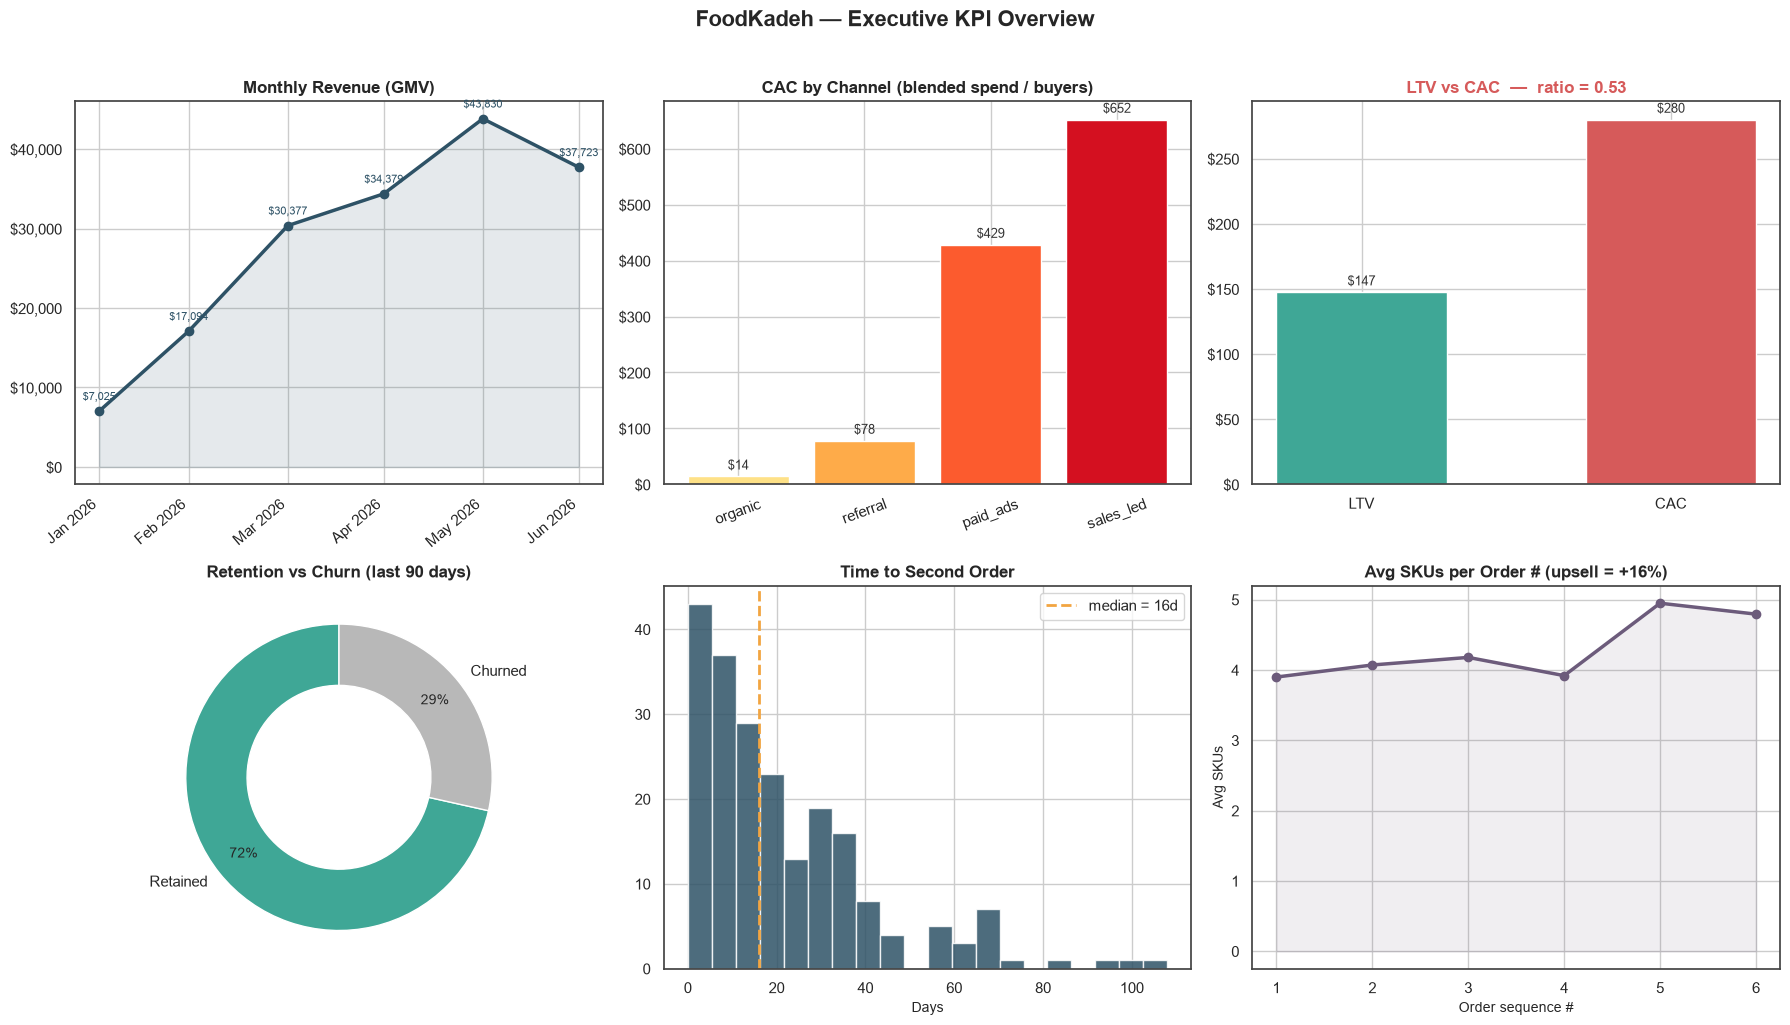

In [6]:
# ========================================================
# FIGURE 1: EXECUTIVE KPI OVERVIEW (restyled, 2x3)
# ========================================================
fig1, axes = plt.subplots(2, 3, figsize=(18, 10))
fig1.suptitle("FoodKadeh — Executive KPI Overview", fontsize=16, fontweight="bold", y=1.02)

# 1. Monthly Revenue trend (area + line, annotated)
monthly_rev = orders_completed.set_index("order_date").resample("ME")["gmv"].sum()
ax = axes[0, 0]
ax.plot(monthly_rev.index, monthly_rev.values, marker="o", color=PALETTE["primary"], lw=2.5, zorder=3)
ax.fill_between(monthly_rev.index, monthly_rev.values, color=PALETTE["primary"], alpha=0.12)
for x, y in zip(monthly_rev.index, monthly_rev.values):
    ax.annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=PALETTE["primary"])
ax.set_title("Monthly Revenue (GMV)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.set_xticks(monthly_rev.index)
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly_rev.index], rotation=40, ha="right")

# 2. CAC by channel (gradient bars, sorted, annotated)
ch_sorted = sorted(CHANNELS, key=lambda c: CHANNEL_SPEND[c] / buyers_per_channel.get(c, 1))
cac_vals_sorted = [CHANNEL_SPEND[c] / buyers_per_channel.get(c, 1) for c in ch_sorted]
colors_cac = sns.color_palette("YlOrRd", len(ch_sorted))
ax = axes[0, 1]
ax.bar(ch_sorted, cac_vals_sorted, color=colors_cac)
annotate_bars(ax, fmt="${:.0f}")
ax.set_title("CAC by Channel (blended spend / buyers)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.tick_params(axis="x", rotation=20)

# 3. LTV vs CAC
ax = axes[0, 2]
ax.bar(["LTV", "CAC"], [ltv, cac_blended], color=[PALETTE["good"], PALETTE["bad"]], width=0.55)
annotate_bars(ax, fmt="${:.0f}")
health_color = PALETTE["good"] if ltv_cac >= 1 else PALETTE["bad"]
ax.set_title(f"LTV vs CAC  —  ratio = {ltv_cac:.2f}", color=health_color)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.axhline(0, color="#999", lw=0.8)

# 4. Retention vs Churn (donut)
ax = axes[1, 0]
ax.pie([retention_rate, churn_rate], labels=["Retained", "Churned"],
       autopct="%1.0f%%", colors=[PALETTE["good"], PALETTE["neutral"]],
       startangle=90, pctdistance=0.8,
       wedgeprops=dict(width=0.4, edgecolor="white"))
ax.set_title("Retention vs Churn (last 90 days)")

# 5. Time to second order
ax = axes[1, 1]
ax.hist(time_to_second, bins=20, color=PALETTE["primary"], alpha=0.85, edgecolor="white")
ax.axvline(time_to_second.median(), color=PALETTE["accent"], linestyle="--", lw=2,
           label=f"median = {time_to_second.median():.0f}d")
ax.set_title("Time to Second Order")
ax.set_xlabel("Days")
ax.legend()

# 6. Upsell: avg SKUs by order sequence
skus_by_seq = orders_completed[orders_completed["order_seq"] <= 6].groupby("order_seq")["n_skus"].mean()
ax = axes[1, 2]
ax.plot(skus_by_seq.index, skus_by_seq.values, marker="o", color=PALETTE["highlight"], lw=2.5)
ax.fill_between(skus_by_seq.index, skus_by_seq.values, color=PALETTE["highlight"], alpha=0.1)
ax.set_title(f"Avg SKUs per Order # (upsell = {upsell_rate:+.0%})")
ax.set_xlabel("Order sequence #")
ax.set_ylabel("Avg SKUs")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig1_executive_kpis.png", dpi=150, bbox_inches="tight")
plt.show()


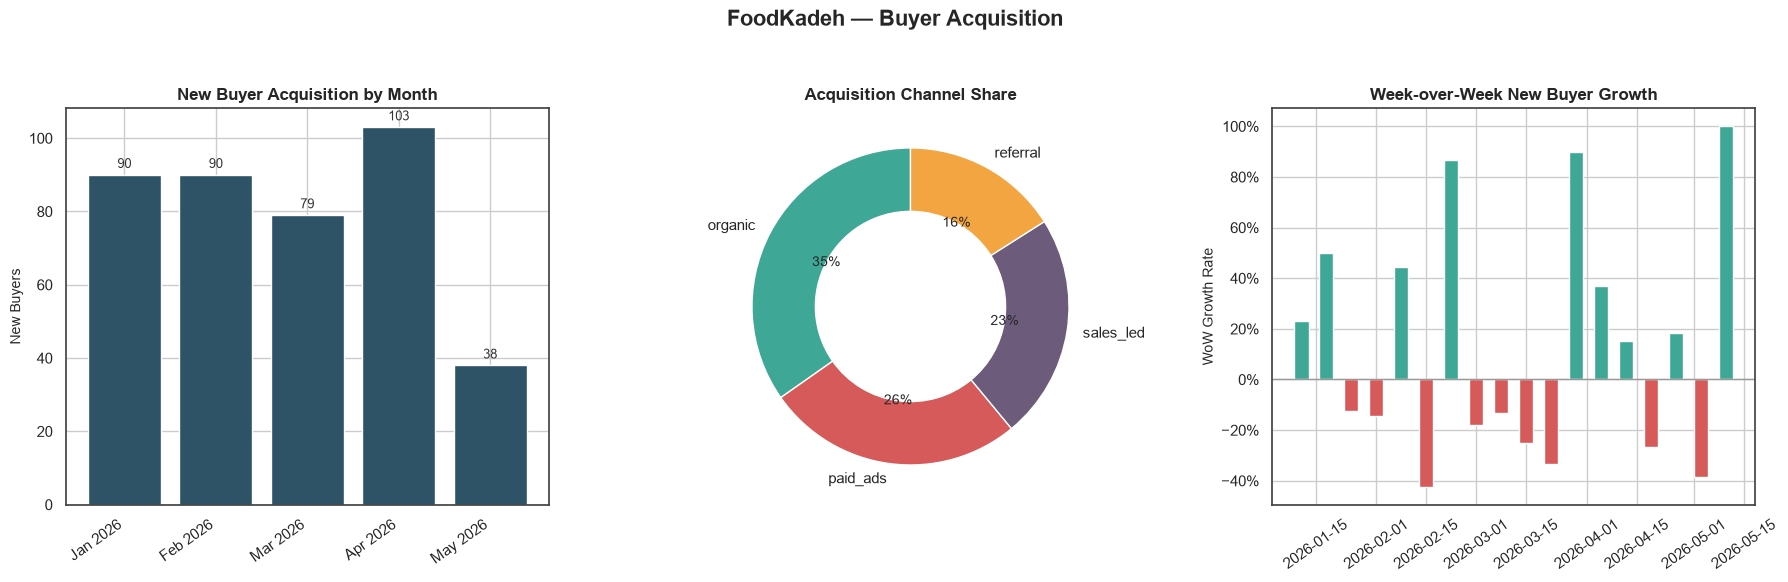

In [7]:
# ========================================================
# FIGURE 2: BUYER ACQUISITION (restyled, 1x3)
# ========================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))
fig2.suptitle("FoodKadeh — Buyer Acquisition", fontsize=16, fontweight="bold", y=1.05)

ax = axes2[0]
ax.bar(new_buyers_monthly["signup_month"], new_buyers_monthly["new_buyers"], color=PALETTE["primary"])
annotate_bars(ax)
ax.set_title("New Buyer Acquisition by Month")
ax.set_ylabel("New Buyers")
ax.set_xticks(range(len(new_buyers_monthly)))
ax.set_xticklabels(
    [pd.Period(m, freq="M").strftime("%b %Y") for m in new_buyers_monthly["signup_month"]],
    rotation=35, ha="right")

ax = axes2[1]
colors_ch = [PALETTE["good"], PALETTE["bad"], PALETTE["highlight"], PALETTE["accent"]]
ax.pie(channel_share["share"], labels=channel_share["channel"], autopct="%1.0f%%",
       colors=colors_ch, startangle=90, wedgeprops=dict(width=0.4, edgecolor="white"))
ax.set_title("Acquisition Channel Share")

ax = axes2[2]
colors_wow = [PALETTE["good"] if v >= 0 else PALETTE["bad"] for v in buyers_weekly["wow_growth"].fillna(0)]
ax.bar(buyers_weekly["signup_date"], buyers_weekly["wow_growth"], color=colors_wow, width=4)
ax.axhline(0, color="#999", lw=1)
ax.set_title("Week-over-Week New Buyer Growth")
ax.set_ylabel("WoW Growth Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig2_acquisition.png", dpi=150, bbox_inches="tight")
plt.show()


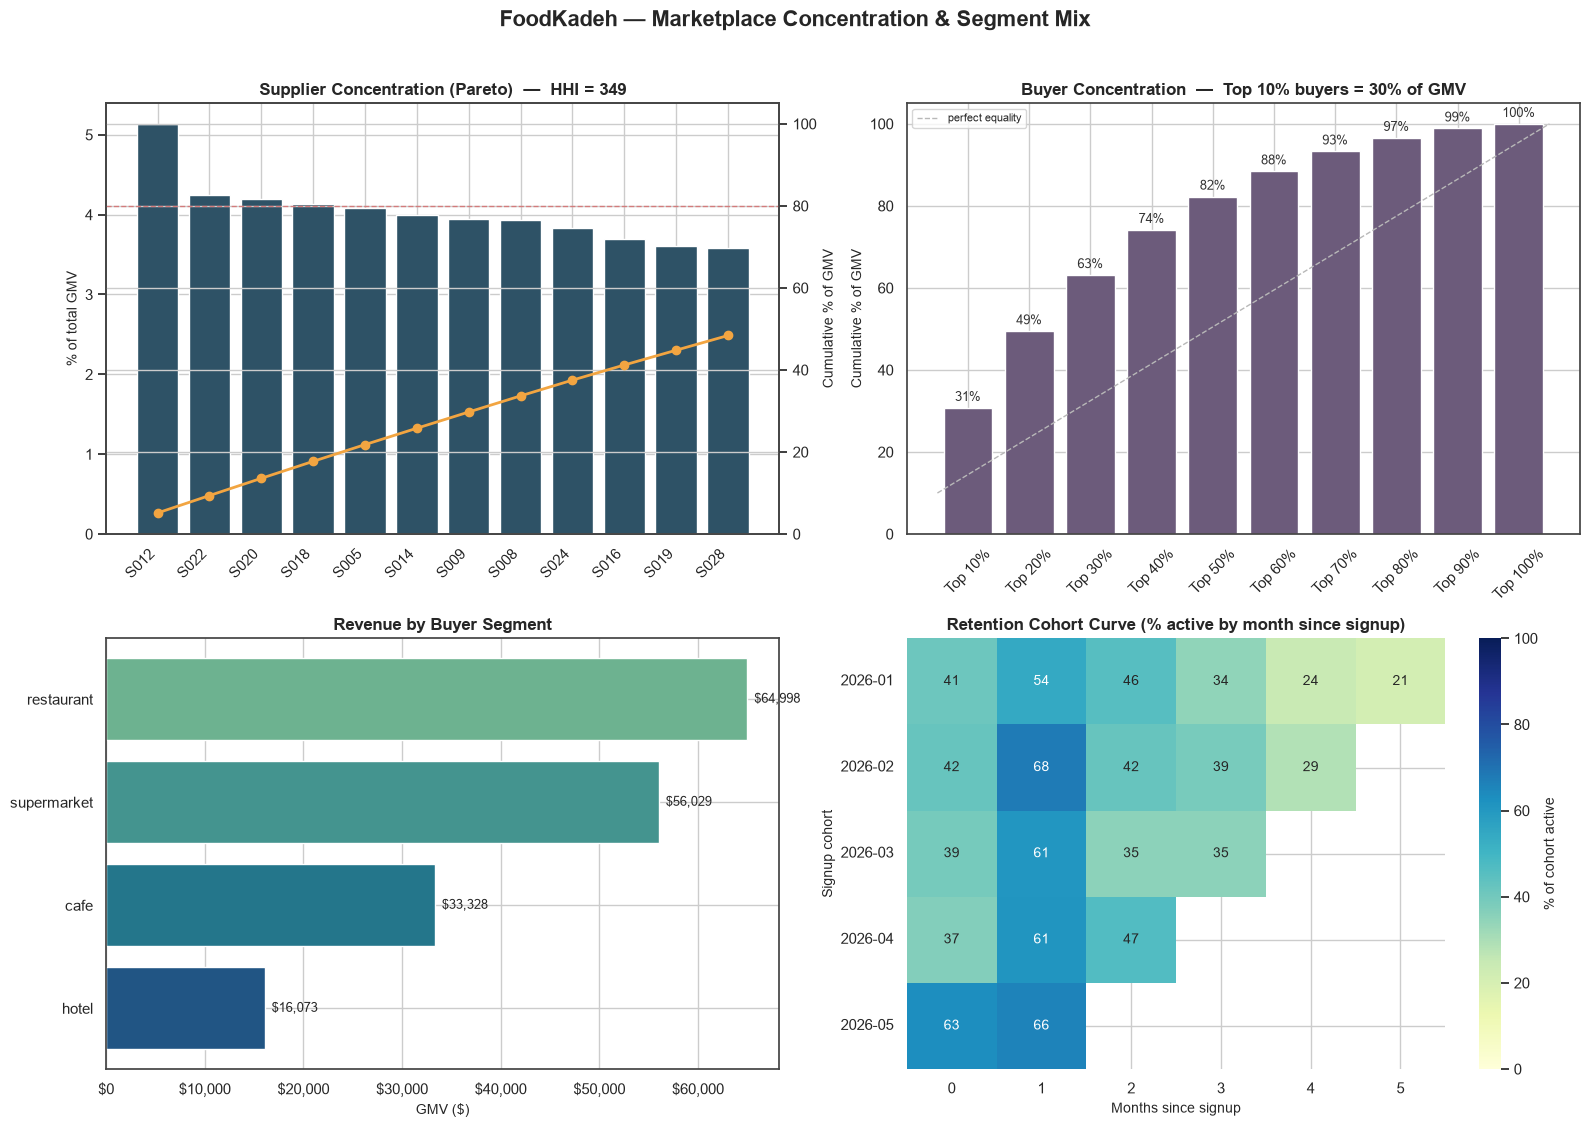

In [8]:
# ========================================================
# FIGURE 3: NEW — MARKETPLACE CONCENTRATION & SEGMENT MIX
# ========================================================
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 11))
fig3.suptitle("FoodKadeh — Marketplace Concentration & Segment Mix", fontsize=16, fontweight="bold", y=1.02)

# 7. Supplier concentration - Pareto chart
ax = axes3[0, 0]
top_n = 12
plot_suppliers = supplier_share.head(top_n)
ax.bar(range(len(plot_suppliers)), plot_suppliers.values * 100, color=PALETTE["primary"])
ax2b = ax.twinx()
ax2b.plot(range(len(plot_suppliers)), cumulative_share.head(top_n).values * 100,
          color=PALETTE["accent"], marker="o", lw=2)
ax2b.axhline(80, color=PALETTE["bad"], linestyle="--", lw=1, alpha=0.7)
ax2b.set_ylim(0, 105)
ax2b.set_ylabel("Cumulative % of GMV")
ax.set_xticks(range(len(plot_suppliers)))
ax.set_xticklabels(plot_suppliers.index, rotation=45, ha="right")
ax.set_ylabel("% of total GMV")
ax.set_title(f"Supplier Concentration (Pareto)  —  HHI = {supplier_hhi:.0f}")

# 8. Buyer concentration - cumulative share by decile
ax = axes3[0, 1]
deciles = np.arange(1, 11)
decile_shares = []
sorted_gmv = buyer_gmv.sort_values(ascending=False).values
n = len(sorted_gmv)
for d in deciles:
    k = int(np.ceil(n * d / 10))
    decile_shares.append(sorted_gmv[:k].sum() / sorted_gmv.sum() * 100)
ax.bar([f"Top {d*10}%" for d in deciles], decile_shares, color=PALETTE["highlight"])
ax.plot([-0.5, 9.5], [10, 100], color=PALETTE["neutral"], linestyle="--", lw=1, label="perfect equality")
annotate_bars(ax, fmt="{:.0f}%")
ax.set_title(f"Buyer Concentration  —  Top 10% buyers = {top10pct_share:.0%} of GMV")
ax.set_ylabel("Cumulative % of GMV")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)

# 9. Buyer segment revenue mix
ax = axes3[1, 0]
colors_seg = sns.color_palette("crest", len(segment_revenue))
bars = ax.barh(segment_revenue.index[::-1], segment_revenue.values[::-1], color=colors_seg[::-1])
for b, v in zip(bars, segment_revenue.values[::-1]):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center",
                ha="left", fontsize=9, xytext=(5, 0), textcoords="offset points")
ax.set_title("Revenue by Buyer Segment")
ax.set_xlabel("GMV ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

# 10. Retention cohort heatmap
ax = axes3[1, 1]
sns.heatmap(retention_matrix * 100, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cohort active"}, ax=ax, vmin=0, vmax=100)
ax.set_title("Retention Cohort Curve (% active by month since signup)")
ax.set_xlabel("Months since signup")
ax.set_ylabel("Signup cohort")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig3_concentration_mix.png", dpi=150, bbox_inches="tight")
plt.show()


Advanced Segmentation & Predictive Analytics

Question: Beyond the executive KPIs and concentration metrics above, which individual buyers matter most, what natural groupings exist in the buyer base, and can we predict who's about to churn before they do?

This section adds four analyses built with scikit-learn on top of the same buyer/order data used throughout the notebook — no new simulation, just deeper modeling of the buyers already generated:

1. RFM Segmentation — scores every buyer on Recency, Frequency, and Monetary value (quintile-based, the standard RFM method) and maps combinations of those scores into named segments (Champions, Loyal, At Risk, Potential Loyalists, New Customers, Lost).
2. Retention Cohort + Purchase Frequency — the cohort heatmap from the earlier section, paired with a simple distribution of how many buyers are one-time vs. occasional vs. regular vs. loyal purchasers.
3. K-Means Clustering — an unsupervised alternative to RFM's rule-based segments: standardizes recency/frequency/monetary and lets K-Means (with the elbow method choosing k=4) discover natural buyer groups, which are then labeled (VIP, Regular, New, Inactive) based on each cluster's average behavior.
4. Churn Prediction — trains a Logistic Regression and a Random Forest to predict which buyers will go quiet (no order in the last 90 days), using order history, tenure, and buyer attributes as features. Includes ROC/AUC comparison, a confusion matrix, and feature importances.

Business use: RFM and K-Means answer "who are our buyers and how should we treat each group differently" (e.g. retention offers for At Risk/Inactive, upsell for Champions/VIP). The churn model answers "which specific buyers are likely to go dormant next month, before they actually do" — the feature importances point to *why* (mainly recent order cadence and tenure), which tells the growth team what early-warning signal to watch.

Caveat: because "churned" is defined here directly from recent order activity, and features like orders-per-month are mechanically tied to that same activity, the model separates the two classes very cleanly (AUC ~0.95-0.97). That's expected given the label definition, not evidence the real-world problem will be this easy — a live churn model would need to predict *before* the drop-off using only earlier-period behavior.

In [9]:
# ================= ADVANCED SEGMENTATION & PREDICTIVE ANALYTICS =================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix

# snapshot date = the day after the observation window ends (used for recency calcs)
SNAPSHOT_DATE = END_DATE + timedelta(days=1)


RFM Segmentation

RFM scores each buyer on three dimensions, using quintiles (5 = best, 1 = worst) so the scoring is relative to this buyer base rather than fixed thresholds:
- Recency (R): days since last order (or since signup, for buyers who never ordered) — lower is better.
- Frequency (F): number of completed orders.
- Monetary (M): total GMV.

Score combinations are then mapped to named segments: Champions (high R, F, and M) are the buyers to protect and reward; At Risk (low recency but historically frequent) are lapsing buyers worth a win-back campaign; Lost (low on both recency and frequency) are unlikely to be worth further spend; New Customers (very recent, low frequency) need onboarding nudges toward a second order.

=== RFM Segments ===
segment
Lost                   101
Loyal                   91
Champions               90
At Risk                 59
Potential Loyalists     37
New Customers           22
Name: count, dtype: int64

Avg revenue per segment:
segment
Champions              876.44
Loyal                  475.04
At Risk                466.54
New Customers          190.61
Potential Loyalists    124.09
Lost                   118.90
Name: monetary, dtype: float64


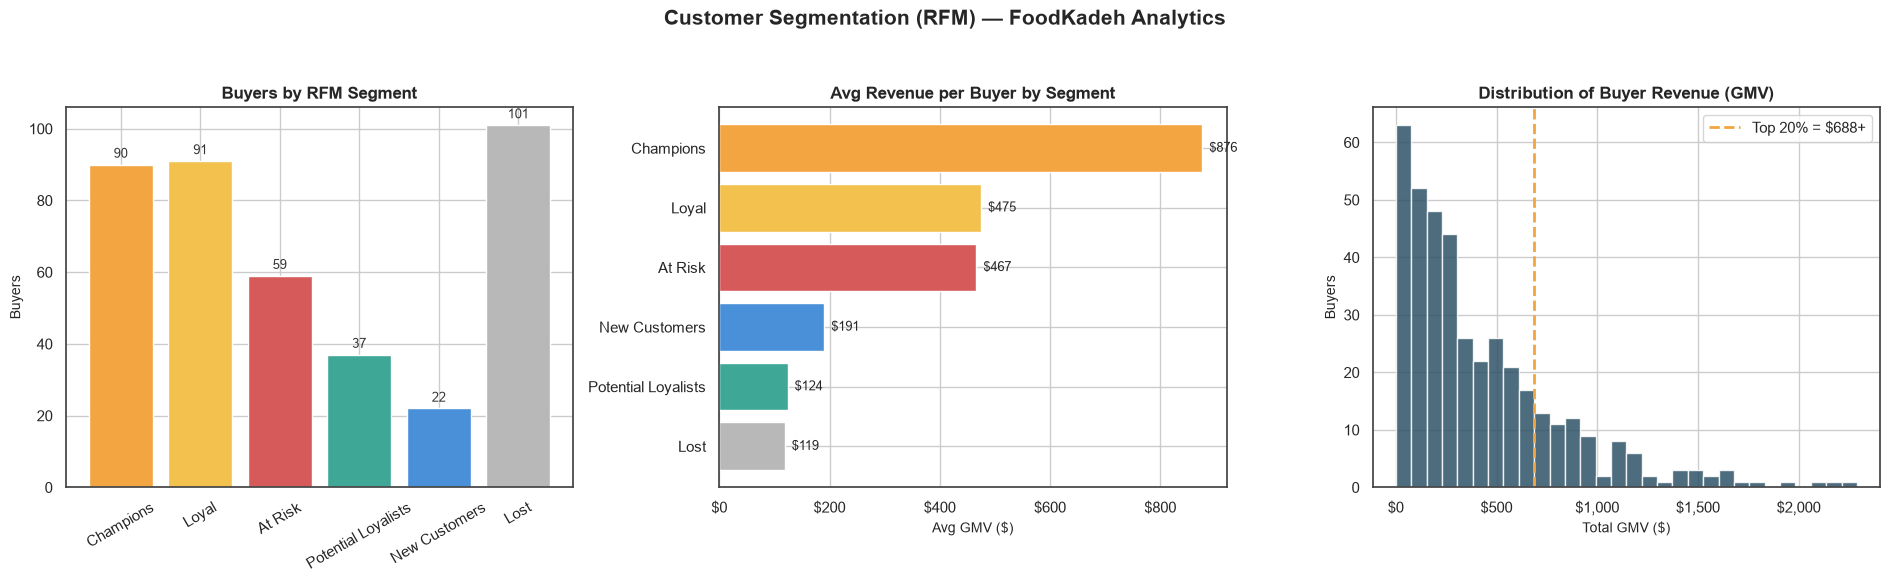

In [10]:
# ---------- RFM TABLE (buyer-level Recency, Frequency, Monetary) ----------
rfm = orders_completed.groupby("buyer_id").agg(
    last_order_date=("order_date", "max"),
    frequency=("order_id", "count"),
    monetary=("gmv", "sum"),
).reindex(buyer_ids)
rfm["frequency"] = rfm["frequency"].fillna(0)
rfm["monetary"] = rfm["monetary"].fillna(0)
rfm = rfm.join(buyers.set_index("buyer_id")[["signup_date", "channel", "buyer_type"]])
rfm["recency"] = (SNAPSHOT_DATE - rfm["last_order_date"]).dt.days
never_ordered = rfm["last_order_date"].isna()
rfm.loc[never_ordered, "recency"] = (SNAPSHOT_DATE - rfm.loc[never_ordered, "signup_date"]).dt.days

# quintile scores: 5 = best. Recency is reversed (lower days = better = higher score)
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1], duplicates="drop").astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment_rfm(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r >= 4 and f <= 2:
        return "New Customers"
    if r <= 2 and f <= 2:
        return "Lost"
    return "Potential Loyalists"

rfm["segment"] = rfm.apply(segment_rfm, axis=1)

print("=== RFM Segments ===")
print(rfm["segment"].value_counts())
print("\nAvg revenue per segment:")
print(rfm.groupby("segment")["monetary"].mean().round(2).sort_values(ascending=False))

# ---------- FIGURE: RFM SEGMENTATION DASHBOARD ----------
SEG_ORDER = ["Champions", "Loyal", "At Risk", "Potential Loyalists", "New Customers", "Lost"]
SEG_COLORS = {
    "Champions": PALETTE["accent"], "At Risk": PALETTE["bad"], "Loyal": "#F2C14E",
    "Potential Loyalists": PALETTE["good"], "New Customers": "#4A90D9", "Lost": PALETTE["neutral"],
}
seg_counts = rfm["segment"].value_counts().reindex(SEG_ORDER, fill_value=0)
seg_avg_rev = rfm.groupby("segment")["monetary"].mean().reindex(SEG_ORDER).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle("Customer Segmentation (RFM) — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.05)

ax = axes[0]
ax.bar(seg_counts.index, seg_counts.values, color=[SEG_COLORS[s] for s in seg_counts.index])
annotate_bars(ax)
ax.set_title("Buyers by RFM Segment")
ax.set_ylabel("Buyers")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
bars = ax.barh(seg_avg_rev.index, seg_avg_rev.values, color=[SEG_COLORS[s] for s in seg_avg_rev.index])
for b, v in zip(bars, seg_avg_rev.values):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center", ha="left",
                fontsize=9, xytext=(5, 0), textcoords="offset points")
ax.set_title("Avg Revenue per Buyer by Segment")
ax.set_xlabel("Avg GMV ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

ax = axes[2]
ax.hist(rfm["monetary"], bins=30, color=PALETTE["primary"], edgecolor="white", alpha=0.85)
top20 = rfm["monetary"].quantile(0.80)
ax.axvline(top20, color=PALETTE["accent"], linestyle="--", lw=2, label=f"Top 20% = ${top20:,.0f}+")
ax.set_title("Distribution of Buyer Revenue (GMV)")
ax.set_xlabel("Total GMV ($)")
ax.set_ylabel("Buyers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_rfm.png", dpi=150, bbox_inches="tight")
plt.show()


🏆 9. RFM Segments — Lost is your biggest bucket
Lost is the single largest segment at 101 buyers (~25% of everyone who's ever ordered), yet worth only $118.90 avg — the least valuable group, and the most numerous.
Champions (90 buyers, $876.44 avg) and At Risk (59 buyers, $466.54 avg) are close in size, but At Risk buyers are worth nearly as much as Loyal buyers ($475.04) while trending toward churn.
👉 At Risk is the highest-leverage win-back target — these buyers already proved they're worth ~$467 each; losing them to the Lost bucket is a bigger loss than losing a New Customer. Champions need retention perks, not more acquisition spend; they're already sold.

Retention Cohorts + Purchase Frequency

The cohort heatmap re-uses the retention_matrix computed earlier in this notebook. Paired here with a purchase-frequency histogram (One-time / Occasional 2-3 / Regular 4-6 / Loyal 7+), it gives a fuller before/after read on the same repeat-purchase question the executive KPI section opened with: not just "what % are retained" but "how deep does that retention actually go."

=== Purchase Frequency Distribution ===
One-time (1)        139
Occasional (2-3)    123
Regular (4-6)        88
Loyal (7+)           26
Name: count, dtype: int64


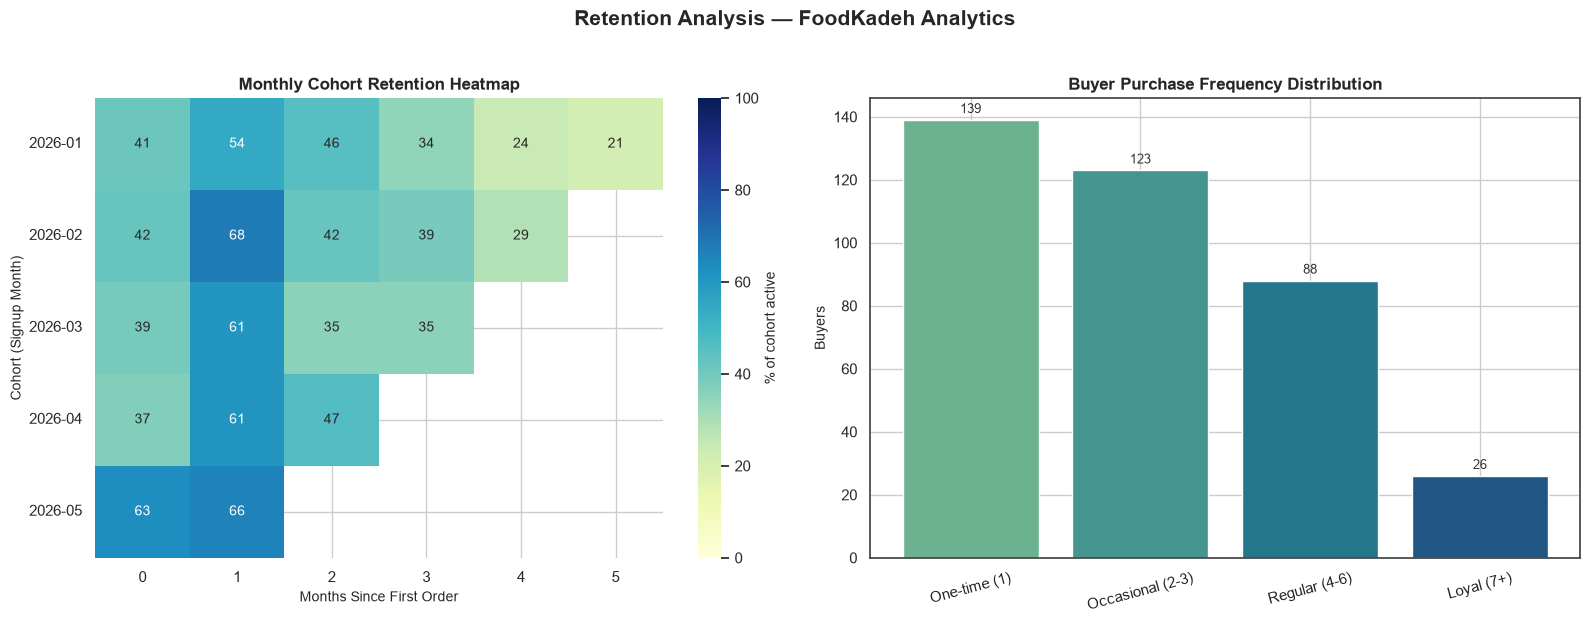

In [11]:
# ---------- Purchase frequency buckets ----------
orders_per_buyer_full = orders_completed.groupby("buyer_id").size().reindex(buyer_ids, fill_value=0)

def freq_bucket(n):
    if n == 0:
        return None
    if n == 1:
        return "One-time (1)"
    if n <= 3:
        return "Occasional (2-3)"
    if n <= 6:
        return "Regular (4-6)"
    return "Loyal (7+)"

FREQ_ORDER = ["One-time (1)", "Occasional (2-3)", "Regular (4-6)", "Loyal (7+)"]
freq_counts = orders_per_buyer_full.apply(freq_bucket).dropna().value_counts().reindex(FREQ_ORDER, fill_value=0)
print("=== Purchase Frequency Distribution ===")
print(freq_counts)

# ---------- FIGURE: RETENTION COHORTS + PURCHASE FREQUENCY ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Retention Analysis — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.03)

ax = axes[0]
sns.heatmap(retention_matrix * 100, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cohort active"}, ax=ax, vmin=0, vmax=100)
ax.set_title("Monthly Cohort Retention Heatmap")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("Cohort (Signup Month)")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax = axes[1]
colors_freq = sns.color_palette("crest", 4)
ax.bar(freq_counts.index, freq_counts.values, color=colors_freq)
annotate_bars(ax)
ax.set_title("Buyer Purchase Frequency Distribution")
ax.set_ylabel("Buyers")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_retention.png", dpi=150, bbox_inches="tight")
plt.show()


📦 10. Purchase Frequency — a steep pyramid
139 buyers (the largest group) have ordered exactly once; only 26 have made it to "Loyal" (7+ orders) — a steep drop-off from One-time → Occasional (123) → Regular (88) → Loyal (26).
👉 Converting even a fraction of the 139 one-time buyers into a 2nd order is the cheapest volume lever available — cheaper than acquiring new buyers, and directly tied to the 16-day median time-to-second-order stat from the executive KPI section. A reorder nudge timed around day 10–16 is the obvious experiment.

K-Means Clustering (unsupervised alternative to RFM)

RFM segmentation uses fixed rules on top of quantile scores. K-Means instead lets the data decide the groupings: recency, frequency, and monetary are standardized (so no single unit dominates distance), and the elbow method is used to pick k — the point where adding more clusters stops meaningfully reducing inertia (within-cluster variance). k=4 is a clear elbow here.

The four discovered clusters are then labeled by their average behavior: the cluster with the highest average revenue becomes "VIP," the one with the highest average recency (least recently active) becomes "Inactive," and the rest split into "Regular" (at/above median order frequency) and "New" (low frequency, more recent signups). This tends to agree with RFM's Champions/At Risk/Lost/New Customers groups directionally, since both are built from the same underlying recency/frequency/monetary signals — but K-Means can reveal a somewhat different grouping shape since it isn't constrained by RFM's fixed scoring rules.

=== K-Means Cluster Profile ===
         recency  frequency  monetary    n     label
cluster                                             
0          116.0        1.3     193.5  121  Inactive
1           30.4        4.2     665.5  112   Regular
2           37.7        1.4     196.2  135       New
3           26.2        7.7    1437.1   32       VIP


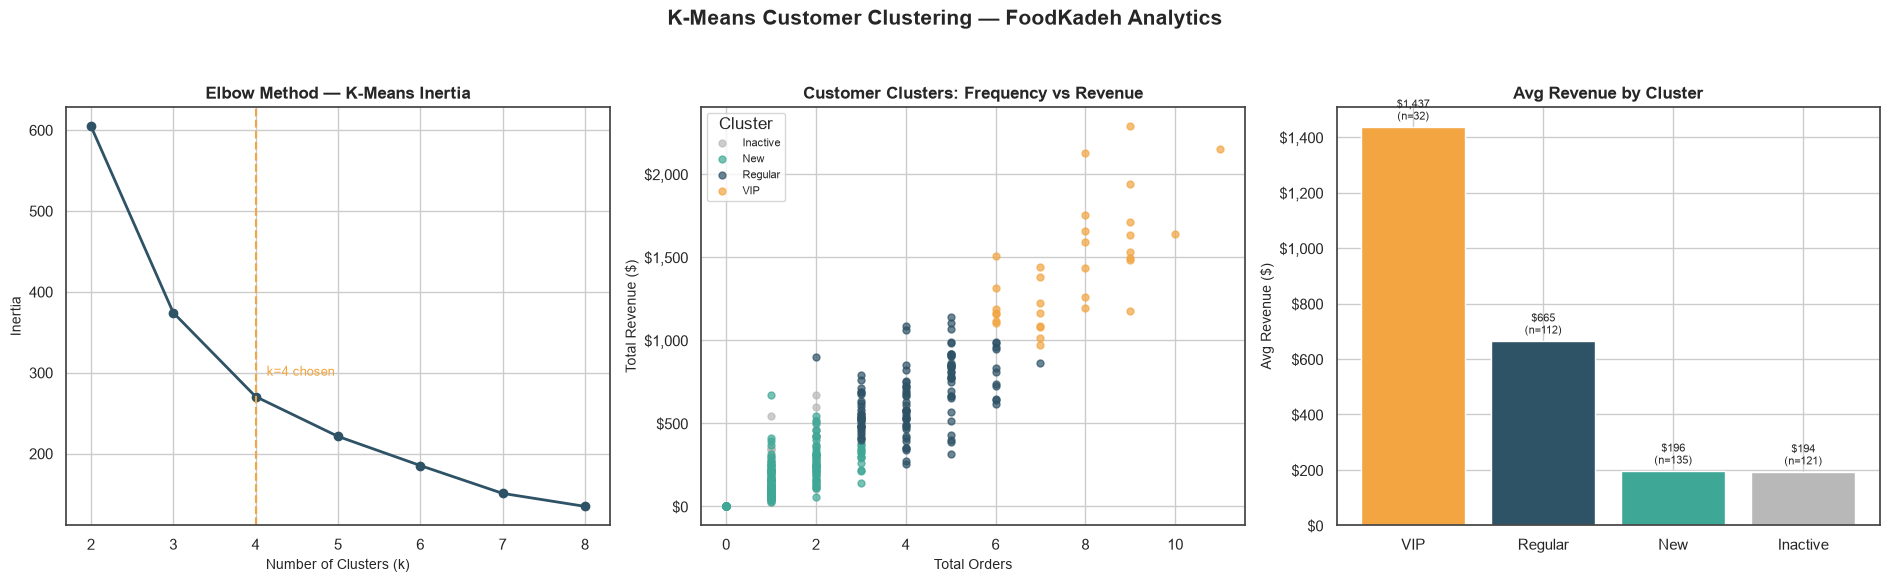

In [12]:
# ---------- K-MEANS on standardized R/F/M ----------
X = rfm[["recency", "frequency", "monetary"]].copy()
X_scaled = StandardScaler().fit_transform(X)

K_range = range(2, 9)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in K_range]

K_OPT = 4  # chosen from the elbow plot below
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()
cluster_profile["n"] = rfm.groupby("cluster").size()

# label clusters by their behavior rather than arbitrary cluster numbers
vip_cluster = cluster_profile["monetary"].idxmax()
inactive_cluster = cluster_profile["recency"].idxmax()
freq_median_all = rfm["frequency"].median()
cluster_labels = {}
for c in cluster_profile.index:
    if c == vip_cluster:
        cluster_labels[c] = "VIP"
    elif c == inactive_cluster:
        cluster_labels[c] = "Inactive"
    elif cluster_profile.loc[c, "frequency"] >= freq_median_all:
        cluster_labels[c] = "Regular"
    else:
        cluster_labels[c] = "New"
rfm["cluster_label"] = rfm["cluster"].map(cluster_labels)
cluster_profile["label"] = cluster_profile.index.map(cluster_labels)

print("=== K-Means Cluster Profile ===")
print(cluster_profile.round(1))

# ---------- FIGURE: K-MEANS CLUSTERING DASHBOARD ----------
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle("K-Means Customer Clustering — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.05)

ax = axes[0]
ax.plot(list(K_range), inertias, marker="o", color=PALETTE["primary"], lw=2)
ax.axvline(K_OPT, color=PALETTE["accent"], linestyle="--", lw=1.5)
ax.annotate(f"k={K_OPT} chosen", (K_OPT, inertias[K_OPT - K_range.start]),
            textcoords="offset points", xytext=(8, 15), color=PALETTE["accent"], fontsize=9)
ax.set_title("Elbow Method — K-Means Inertia")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")

ax = axes[1]
cluster_colors = {"VIP": PALETTE["accent"], "Regular": PALETTE["primary"],
                   "New": PALETTE["good"], "Inactive": PALETTE["neutral"]}
for label, sub in rfm.groupby("cluster_label"):
    ax.scatter(sub["frequency"], sub["monetary"], s=25, alpha=0.7,
               color=cluster_colors.get(label, "gray"), label=label)
ax.set_title("Customer Clusters: Frequency vs Revenue")
ax.set_xlabel("Total Orders")
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.legend(title="Cluster", fontsize=8)

ax = axes[2]
avg_rev_cluster = rfm.groupby("cluster_label").agg(avg_rev=("monetary", "mean"), n=("monetary", "size"))
avg_rev_cluster = avg_rev_cluster.sort_values("avg_rev", ascending=False)
bars = ax.bar(avg_rev_cluster.index, avg_rev_cluster["avg_rev"],
              color=[cluster_colors.get(c, "gray") for c in avg_rev_cluster.index])
for b, (rev, n) in zip(bars, zip(avg_rev_cluster["avg_rev"], avg_rev_cluster["n"])):
    ax.annotate(f"${rev:,.0f}\n(n={n})", (b.get_x() + b.get_width() / 2, rev),
                ha="center", va="bottom", fontsize=8, xytext=(0, 3), textcoords="offset points")
ax.set_title("Avg Revenue by Cluster")
ax.set_ylabel("Avg Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()


🎯 11. K-Means Clusters — New and Inactive look the same on paper, but aren't
VIP (32 buyers, $1,437 avg) is a narrower, higher-value group than RFM's Champions (90 buyers) — K-Means found a tighter top tier using recency+frequency+monetary jointly rather than fixed rules.
New (135 buyers, $196 avg) and Inactive (121 buyers, $194 avg) have almost identical average revenue, despite being opposite stories: one is buyers who haven't ramped up yet, the other is buyers who already went quiet.
👉 Don't treat New and Inactive the same operationally just because their revenue numbers match — New needs onboarding pushes, Inactive needs a win-back offer (or should be written off if it doesn't respond).

Churn Prediction Models

A buyer is labeled "churned" if they have no completed order in the last 90 days of the observation window (the same definition used for the retention/churn KPI earlier in this notebook). Features: total orders, total revenue, average order value, average SKUs per order, customer lifetime (days since signup), orders per month, acquisition channel, and buyer type (one-hot encoded).

Two models are compared: Logistic Regression (a simple, interpretable linear baseline) and Random Forest (captures non-linear interactions, and exposes feature importances). Both are evaluated with ROC/AUC on a held-out 30% test split, and the Random Forest's predictions are also shown as a confusion matrix. The feature importances show which signals the model actually leans on — here it's dominated by order cadence (orders per month) and tenure, which lines up with intuition: a buyer who has slowed down and has been around a while without ordering is the clearest churn signal.

=== Churn Prediction ===
AUC — Logistic Regression: 0.974 | Random Forest: 0.949
Confusion matrix (Random Forest):
 [[84  2]
 [10 24]]

Top feature importances:
 orders_per_month          0.371
customer_lifetime_days    0.177
total_revenue             0.140
total_orders              0.105
avg_order_value           0.095
avg_skus                  0.072
type_restaurant           0.007
type_supermarket          0.006
channel_organic           0.006
channel_sales_led         0.005
dtype: float64


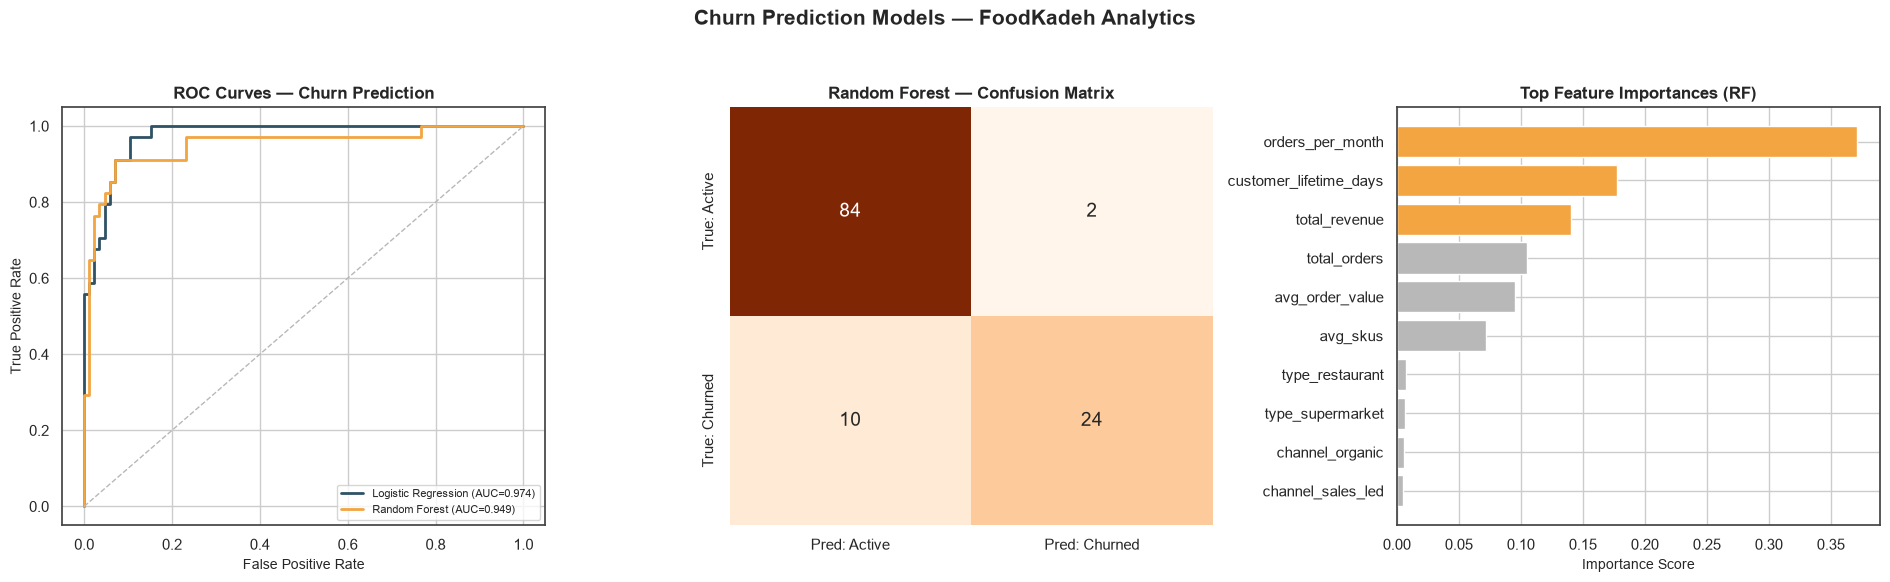

In [13]:
# ---------- Buyer-level feature table for churn prediction ----------
agg = orders_completed.groupby("buyer_id").agg(
    total_orders=("order_id", "count"),
    total_revenue=("gmv", "sum"),
    avg_order_value=("gmv", "mean"),
    avg_skus=("n_skus", "mean"),
    last_order_date=("order_date", "max"),
).reindex(buyer_ids)

feat = buyers.set_index("buyer_id").join(agg)
for col in ["total_orders", "total_revenue", "avg_order_value", "avg_skus"]:
    feat[col] = feat[col].fillna(0)
feat["customer_lifetime_days"] = (SNAPSHOT_DATE - feat["signup_date"]).dt.days
feat["orders_per_month"] = (feat["total_orders"] / (feat["customer_lifetime_days"] / 30).replace(0, np.nan)).fillna(0)

# same churn definition used earlier in the notebook: no order in the last 90 days
cutoff = END_DATE - timedelta(days=90)
feat["churned"] = ((feat["last_order_date"].isna()) | (feat["last_order_date"] < cutoff)).astype(int)

feat_dummies = pd.get_dummies(feat[["channel", "buyer_type"]], prefix=["channel", "type"])
num_cols = ["total_orders", "total_revenue", "avg_order_value", "avg_skus",
            "customer_lifetime_days", "orders_per_month"]
Xc = pd.concat([feat[num_cols], feat_dummies], axis=1)
yc = feat["churned"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.3, random_state=42, stratify=yc)
scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s = scaler.transform(Xc_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(Xc_train_s, yc_train)
logreg_proba = logreg.predict_proba(Xc_test_s)[:, 1]

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf_clf.fit(Xc_train, yc_train)
rf_proba = rf_clf.predict_proba(Xc_test)[:, 1]
rf_pred = rf_clf.predict(Xc_test)

fpr_lr, tpr_lr, _ = roc_curve(yc_test, logreg_proba)
fpr_rf, tpr_rf, _ = roc_curve(yc_test, rf_proba)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
cm = confusion_matrix(yc_test, rf_pred)
importances = pd.Series(rf_clf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(10)

print("=== Churn Prediction ===")
print(f"AUC — Logistic Regression: {auc_lr:.3f} | Random Forest: {auc_rf:.3f}")
print("Confusion matrix (Random Forest):\n", cm)
print("\nTop feature importances:\n", importances.round(3))

# ---------- FIGURE: CHURN PREDICTION DASHBOARD ----------
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle("Churn Prediction Models — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.05)

ax = axes[0]
ax.plot(fpr_lr, tpr_lr, color=PALETTE["primary"], lw=2, label=f"Logistic Regression (AUC={auc_lr:.3f})")
ax.plot(fpr_rf, tpr_rf, color=PALETTE["accent"], lw=2, label=f"Random Forest (AUC={auc_rf:.3f})")
ax.plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", lw=1)
ax.set_title("ROC Curves — Churn Prediction")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=ax,
            xticklabels=["Pred: Active", "Pred: Churned"],
            yticklabels=["True: Active", "True: Churned"], annot_kws={"size": 14})
ax.set_title("Random Forest — Confusion Matrix")

ax = axes[2]
colors_imp = [PALETTE["accent"] if v >= importances.iloc[2] else PALETTE["neutral"] for v in importances.values]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors_imp[::-1])
ax.set_title("Top Feature Importances (RF)")
ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_churn.png", dpi=150, bbox_inches="tight")
plt.show()


⚠️ 12. Churn Model — cadence beats identity
Random Forest catches 24 of 34 actual churners in the test set (71% recall) with only 2 false alarms among active buyers — 91.5% overall accuracy.
Feature importances are dominated by orders_per_month (0.371), customer_lifetime_days (0.177), and total_revenue (0.140); buyer type and acquisition channel each contribute under 1%.
👉 Who a buyer is (city, type, channel) barely matters to churn — how their order cadence is trending does. The actionable version of this model isn't "predict churn," it's "alert when a buyer's orders-per-month drops meaningfully below their own historical average."

Operational Insights

Question: Beyond who's buying and how much, where and what is the marketplace actually moving?

This section adds an operational, logistics-facing view: which product categories drive revenue, how performance differs by city, how delivery speed varies geographically, and how order value differs by buyer type. Two new attributes are introduced to support this — buyer city and supplier product category — generated with a separate random generator (not the seed=42 stream used for buyers/orders/suppliers), so none of the revenue, CAC, LTV, retention, RFM, clustering, or churn numbers reported earlier in this notebook change.

One adaptation from a typical B2C operational dashboard: buyers here are organizations (supermarkets, restaurants, cafes, hotels), not individual shoppers, so there's no "age group" to segment by. Average Order Value by Buyer Type is used instead — the direct B2B equivalent of asking "which kind of customer spends the most per order."

Business use: product category mix tells the supply/sourcing team where to prioritize new supplier relationships (Grocery Staples and Fresh Produce dominate revenue here). City-level revenue and AOV flag expansion priorities — Tehran leads on both volume and is competitive on AOV, while Tabriz has the highest AOV despite the lowest volume, suggesting a smaller but higher-value buyer base worth growing. Delivery time by city is the fulfillment team's dashboard — a city creeping upward in delivery minutes is an early warning before it shows up as a retention or satisfaction problem.

=== Operational Insights ===

Revenue by product category:
product_category
Grocery Staples    61816.91
Fresh Produce      50049.69
Bakery             24224.66
Dairy & Eggs       15514.63
Beverages          12087.11
Snacks              6734.82
Name: gmv, dtype: float64

City stats:
          revenue    aov
city                   
Tehran   64819.9  157.7
Mashhad  34835.0  153.5
Shiraz   25816.5  159.4
Isfahan  25368.8  162.6
Tabriz   19587.6  168.9

Avg delivery time by city (min):
 city
Isfahan    33.8
Tabriz     35.0
Shiraz     35.8
Tehran     37.1
Mashhad    38.3
Name: delivery_time_min, dtype: float64

AOV by buyer type:
 buyer_type
supermarket    163.35
restaurant     161.69
hotel          153.08
cafe           150.13
Name: gmv, dtype: float64


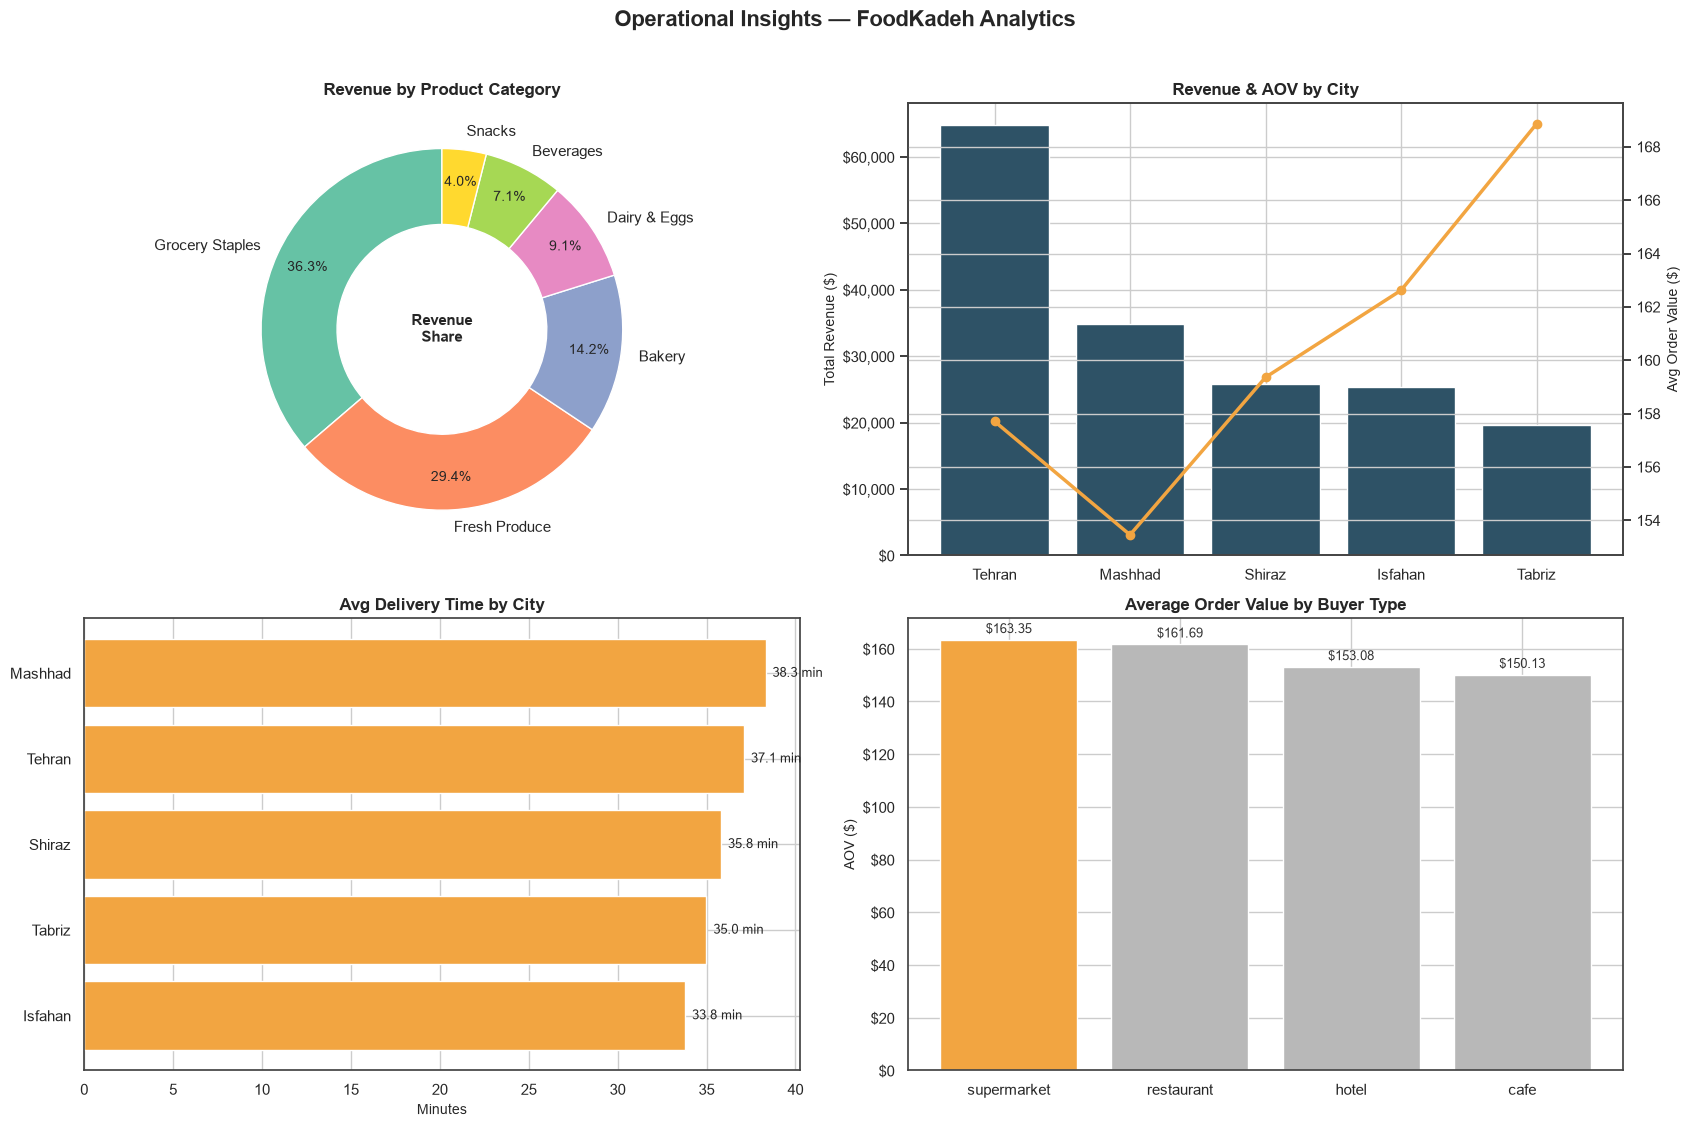

In [14]:
# ---------- Synthetic operational attributes ----------
# A separate random generator is used here (not np.random / seed=42) so this section
# adds new operational dimensions without changing any of the buyer/order/KPI numbers
# reported earlier in the notebook.
ops_rng = np.random.default_rng(123)

CITIES = ["Tehran", "Mashhad", "Shiraz", "Isfahan", "Tabriz"]
CITY_WEIGHTS = [0.34, 0.22, 0.19, 0.14, 0.11]
CITY_BASE_DELIVERY = {"Tehran": 37, "Mashhad": 38, "Shiraz": 36, "Isfahan": 34, "Tabriz": 35}

buyers_ops = buyers.copy()
buyers_ops["city"] = ops_rng.choice(CITIES, size=len(buyers_ops), p=CITY_WEIGHTS)

# each supplier specializes in one product category (assigned so every category is represented)
PRODUCT_CATEGORIES = ["Grocery Staples", "Fresh Produce", "Bakery", "Dairy & Eggs", "Beverages", "Snacks"]
CATEGORY_WEIGHTS = np.array([0.36, 0.30, 0.12, 0.10, 0.07, 0.05])
n_sup = len(suppliers)
raw_counts = CATEGORY_WEIGHTS * n_sup
cat_counts = np.maximum(1, np.floor(raw_counts)).astype(int)
while cat_counts.sum() > n_sup:
    cat_counts[np.argmax(cat_counts)] -= 1
while cat_counts.sum() < n_sup:
    cat_counts[np.argmax(raw_counts - cat_counts)] += 1
cat_assignment = np.repeat(PRODUCT_CATEGORIES, cat_counts)
ops_rng.shuffle(cat_assignment)
suppliers_ops = suppliers.copy()
suppliers_ops["product_category"] = cat_assignment

orders_ops = orders_completed.merge(suppliers_ops[["supplier_id", "product_category"]], on="supplier_id")
orders_ops = orders_ops.merge(buyers_ops[["buyer_id", "city", "buyer_type"]], on="buyer_id")
orders_ops["delivery_time_min"] = (
    orders_ops["city"].map(CITY_BASE_DELIVERY) + ops_rng.normal(0, 4, len(orders_ops))
).clip(lower=10)

# ---------- aggregates ----------
category_revenue = orders_ops.groupby("product_category")["gmv"].sum().sort_values(ascending=False)
city_stats = orders_ops.groupby("city").agg(
    revenue=("gmv", "sum"), aov=("gmv", "mean")).sort_values("revenue", ascending=False)
delivery_by_city = orders_ops.groupby("city")["delivery_time_min"].mean().sort_values()
aov_by_type = orders_ops.groupby("buyer_type")["gmv"].mean().sort_values(ascending=False)

print("=== Operational Insights ===")
print("\nRevenue by product category:")
print(category_revenue)
print("\nCity stats:\n", city_stats.round(1))
print("\nAvg delivery time by city (min):\n", delivery_by_city.round(1))
print("\nAOV by buyer type:\n", aov_by_type.round(2))

# ---------- FIGURE: OPERATIONAL INSIGHTS DASHBOARD ----------
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle("Operational Insights — FoodKadeh Analytics", fontsize=16, fontweight="bold", y=1.02)

# 1. Revenue by product category (donut)
ax = axes[0, 0]
cat_colors = sns.color_palette("Set2", len(category_revenue))
ax.pie(category_revenue.values, labels=category_revenue.index, autopct="%1.1f%%",
       colors=cat_colors, startangle=90, pctdistance=0.82,
       wedgeprops=dict(width=0.42, edgecolor="white"))
ax.text(0, 0, "Revenue\nShare", ha="center", va="center", fontsize=11, fontweight="bold")
ax.set_title("Revenue by Product Category")

# 2. Revenue & AOV by city (dual-axis bar + line)
ax = axes[0, 1]
ax.bar(city_stats.index, city_stats["revenue"], color=PALETTE["primary"])
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax2 = ax.twinx()
ax2.plot(city_stats.index, city_stats["aov"], color=PALETTE["accent"], marker="o", lw=2.5)
ax2.set_ylabel("Avg Order Value ($)")
ax.set_title("Revenue & AOV by City")

# 3. Avg delivery time by city (horizontal bar)
ax = axes[1, 0]
bars = ax.barh(delivery_by_city.index, delivery_by_city.values, color=PALETTE["accent"])
for b, v in zip(bars, delivery_by_city.values):
    ax.annotate(f"{v:.1f} min", (v, b.get_y() + b.get_height() / 2), va="center", ha="left",
                fontsize=9, xytext=(5, 0), textcoords="offset points")
ax.set_title("Avg Delivery Time by City")
ax.set_xlabel("Minutes")

# 4. AOV by buyer type (B2B analogue of "age group" — buyers here are organizations, not individuals)
ax = axes[1, 1]
colors_type = [PALETTE["accent"] if v == aov_by_type.max() else PALETTE["neutral"] for v in aov_by_type.values]
ax.bar(aov_by_type.index, aov_by_type.values, color=colors_type)
annotate_bars(ax, fmt="${:.2f}")
ax.set_title("Average Order Value by Buyer Type")
ax.set_ylabel("AOV ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_operational.png", dpi=150, bbox_inches="tight")
plt.show()


🏙️ 13. Operational Mix — two categories, one slow city
Grocery Staples and Fresh Produce alone make up 65.7% of revenue ($61,817 + $50,050) — the other four categories split the remaining third.
Tabriz has the smallest revenue ($19,588) but the highest AOV ($168.90) and near-fastest delivery (35.0 min) — a small, high-value buyer base. Mashhad is the opposite pattern: 2nd-highest revenue ($34,835) but the slowest delivery of any city (38.3 min).
👉 Tabriz's profile (small, high-value, fast delivery) is worth deliberately replicating elsewhere. Mashhad's combination of high volume and the slowest delivery is worth checking against Mashhad's retention specifically — that's exactly the kind of operational drag that shows up as churn before anyone connects the dots.

New Business Question — Marketplace Take Rate & Platform Unit Economics

Question: Every KPI computed so far — revenue, gross margin, LTV, LTV/CAC, RFM, clustering, churn — has been built from the supplier's side of the transaction: the gross profit a supplier earns after their own cost of goods. None of it answers a more fundamental question for a marketplace business: how much does FoodKadeh itself earn as the platform operator, and is that commission enough to justify what it costs to acquire a buyer?

New KPI introduced: Take Rate — the percentage of GMV that FoodKadeh keeps as its own commission on each transaction, and Platform Revenue — the dollar amount that commission produces. Take rate is modeled to vary by product category (thin-margin staples like Grocery Staples command a lower, more competitive take rate; differentiated or perishable categories like Snacks and Bakery can support a higher one), which is standard marketplace commission design and lets us also ask which categories are most valuable to FoodKadeh specifically, as opposed to which are most valuable to suppliers.

This reuses the product category and city fields from the Operational Insights section and adds take rate with its own independent random generator (seed 456) — it does not touch buyers, orders, GMV, or any KPI computed earlier.

Why this matters: LTV/CAC was already flagged as weak (0.53) using supplier gross profit as the "value" FoodKadeh gets from a buyer — but FoodKadeh never actually collects that gross profit; the supplier does. The number that actually lands in FoodKadeh's own revenue is the take-rate commission. Recomputing LTV/CAC on platform revenue instead gives the real answer to "is our acquisition spend justified by what the marketplace itself earns" — and it's a materially different, more sobering picture than the gross-profit view suggested.

=== Marketplace Take Rate & Platform Economics ===
Total GMV: $170,428
Total Platform Revenue: $16,532
Effective blended take rate: 9.70%

Platform LTV (avg platform revenue/buyer): $41.33
CAC (blended): $280.00
Platform LTV/CAC: 0.148   (vs. supplier gross-profit LTV/CAC computed earlier: 0.527)

Platform revenue & take rate by category:
                  platform_rev       gmv  take_rate
product_category                                   
Fresh Produce         5022.253  50049.69      0.100
Grocery Staples       4949.185  61816.91      0.080
Bakery                2919.229  24224.66      0.121
Dairy & Eggs          1386.351  15514.63      0.089
Beverages             1309.502  12087.11      0.108
Snacks                 945.827   6734.82      0.140


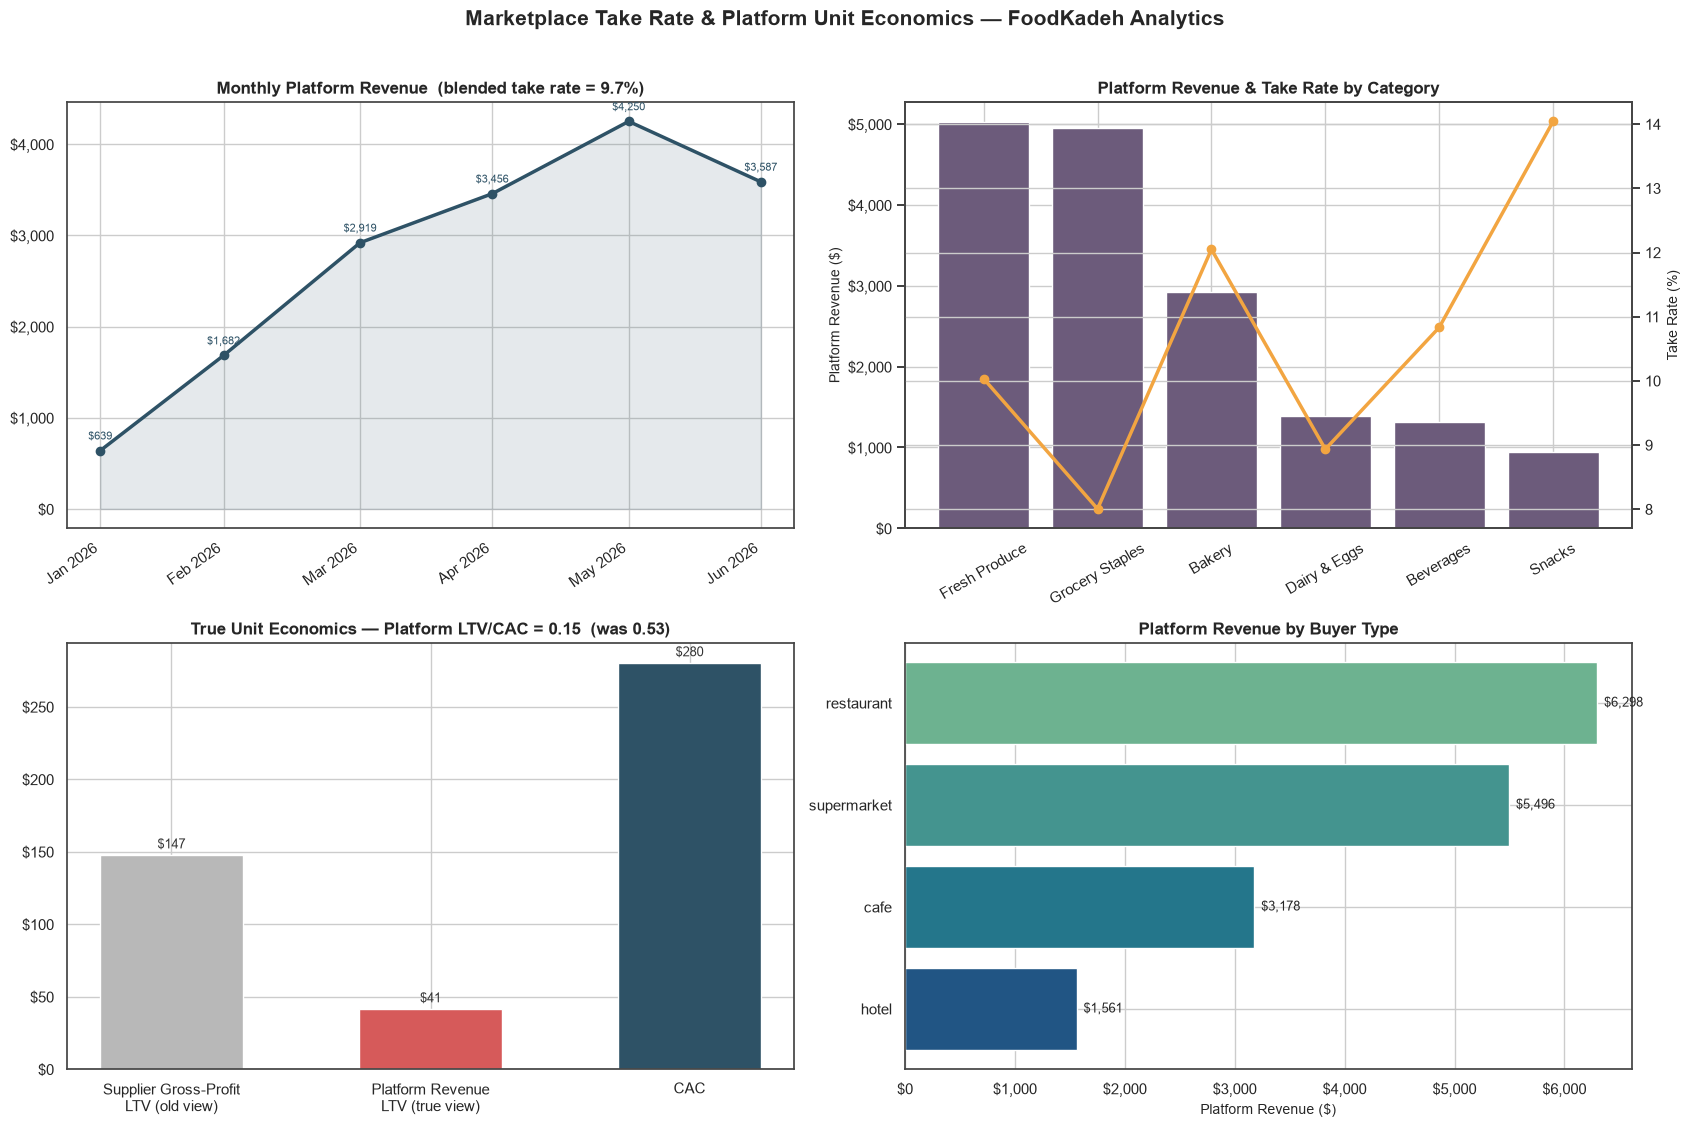

In [15]:
# ---------- Platform take rate model ----------
# Reuses orders_ops (product_category, city, buyer_type) from the Operational Insights section.
# A separate RNG (seed 456) generates the take rate — doesn't touch any prior random stream.
tr_rng = np.random.default_rng(456)

# Commission logic: thin-margin staple categories are priced competitively (lower take rate);
# differentiated / perishable / higher-margin categories can support a higher platform cut.
TAKE_RATE_BY_CATEGORY = {
    "Grocery Staples": 0.08, "Fresh Produce": 0.10, "Dairy & Eggs": 0.09,
    "Beverages": 0.11, "Bakery": 0.12, "Snacks": 0.14,
}
orders_ops["take_rate"] = orders_ops["product_category"].map(TAKE_RATE_BY_CATEGORY)
orders_ops["take_rate"] += tr_rng.normal(0, 0.008, len(orders_ops))
orders_ops["take_rate"] = orders_ops["take_rate"].clip(0.04, 0.20)
orders_ops["platform_revenue"] = orders_ops["gmv"] * orders_ops["take_rate"]

total_gmv = orders_ops["gmv"].sum()
total_platform_rev = orders_ops["platform_revenue"].sum()
effective_take_rate = total_platform_rev / total_gmv

cat_platform = orders_ops.groupby("product_category").agg(
    platform_rev=("platform_revenue", "sum"), gmv=("gmv", "sum")
).assign(take_rate=lambda x: x["platform_rev"] / x["gmv"]).sort_values("platform_rev", ascending=False)

monthly_platform = orders_ops.set_index("order_date").resample("ME")["platform_revenue"].sum()

# ---------- True platform-native LTV/CAC (replaces the supplier-gross-profit view) ----------
plat_rev_per_buyer = orders_ops.groupby("buyer_id")["platform_revenue"].sum().reindex(buyer_ids, fill_value=0)
platform_ltv = plat_rev_per_buyer.mean()
platform_ltv_cac = platform_ltv / cac_blended  # cac_blended computed earlier in the notebook

print("=== Marketplace Take Rate & Platform Economics ===")
print(f"Total GMV: ${total_gmv:,.0f}")
print(f"Total Platform Revenue: ${total_platform_rev:,.0f}")
print(f"Effective blended take rate: {effective_take_rate:.2%}")
print(f"\nPlatform LTV (avg platform revenue/buyer): ${platform_ltv:,.2f}")
print(f"CAC (blended): ${cac_blended:,.2f}")
print(f"Platform LTV/CAC: {platform_ltv_cac:.3f}   (vs. supplier gross-profit LTV/CAC computed earlier: {ltv_cac:.3f})")
print("\nPlatform revenue & take rate by category:")
print(cat_platform.round(3))

# ---------- FIGURE: MARKETPLACE TAKE RATE & PLATFORM UNIT ECONOMICS ----------
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle("Marketplace Take Rate & Platform Unit Economics — FoodKadeh Analytics",
             fontsize=15, fontweight="bold", y=1.02)

# 1. Monthly platform revenue trend
ax = axes[0, 0]
ax.plot(monthly_platform.index, monthly_platform.values, marker="o", color=PALETTE["primary"], lw=2.5)
ax.fill_between(monthly_platform.index, monthly_platform.values, color=PALETTE["primary"], alpha=0.12)
for x, y in zip(monthly_platform.index, monthly_platform.values):
    ax.annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=8, color=PALETTE["primary"])
ax.set_title(f"Monthly Platform Revenue  (blended take rate = {effective_take_rate:.1%})")
ax.set_xticks(monthly_platform.index)
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly_platform.index], rotation=35, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

# 2. Platform revenue & take rate by product category
ax = axes[0, 1]
ax.bar(cat_platform.index, cat_platform["platform_rev"], color=PALETTE["highlight"])
ax.set_ylabel("Platform Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.tick_params(axis="x", rotation=30)
ax2 = ax.twinx()
ax2.plot(cat_platform.index, cat_platform["take_rate"] * 100, color=PALETTE["accent"], marker="o", lw=2.5)
ax2.set_ylabel("Take Rate (%)")
ax.set_title("Platform Revenue & Take Rate by Category")

# 3. True unit economics: old (gross-profit) LTV vs new (platform) LTV vs CAC
ax = axes[1, 0]
bars = ax.bar(["Supplier Gross-Profit\nLTV (old view)", "Platform Revenue\nLTV (true view)", "CAC"],
              [ltv, platform_ltv, cac_blended],
              color=[PALETTE["neutral"], PALETTE["bad"], PALETTE["primary"]], width=0.55)
annotate_bars(ax, fmt="${:.0f}")
ax.set_title(f"True Unit Economics — Platform LTV/CAC = {platform_ltv_cac:.2f}  (was {ltv_cac:.2f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

# 4. Platform revenue by buyer type
ax = axes[1, 1]
by_type = orders_ops.groupby("buyer_type")["platform_revenue"].sum().sort_values(ascending=False)
colors_type = sns.color_palette("crest", len(by_type))
bars = ax.barh(by_type.index[::-1], by_type.values[::-1], color=colors_type[::-1])
for b, v in zip(bars, by_type.values[::-1]):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center", ha="left",
                fontsize=9, xytext=(5, 0), textcoords="offset points")
ax.set_title("Platform Revenue by Buyer Type")
ax.set_xlabel("Platform Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_takerate.png", dpi=150, bbox_inches="tight")
plt.show()


💸 14. Take Rate — the volume categories are the real lever
Snacks carries the highest take rate (14%) but contributes the least platform revenue ($946); Grocery Staples has the lowest take rate (8%) but the most platform revenue ($4,949), almost tied with Fresh Produce ($5,022 at 10%).
Platform LTV/CAC sits at 0.148 — buyer growth alone won't fix that gap; the commission structure has to move.
👉 A 1–2 point take-rate increase on Grocery Staples or Fresh Produce (the volume leaders) would add more platform dollars than raising Snacks' already-highest rate further. That's a bigger, faster lever on unit economics than trying to out-grow a 0.15 LTV/CAC with more acquisition spend.

Marketplace Liquidity — Buyer-to-Supplier Balance

Question: Is FoodKadeh's supplier base keeping pace with its buyer growth, or is the marketplace becoming supply-constrained?

Every KPI so far has looked at buyers or suppliers separately. This section looks at the balance between the two sides of the marketplace, which is the thing that actually determines whether the marketplace stays healthy as it grows. A marketplace with too many buyers chasing too few active suppliers will see fill problems, slower response times, and buyers eventually going around the platform to source directly. A marketplace with plenty of suppliers but few buyers has the opposite problem: suppliers churn out because there isn't enough demand to justify staying.

Two metrics are tracked monthly: the number of distinct buyers and distinct suppliers who transacted that month (active buyers / active suppliers), and the buyer-to-supplier ratio this implies. A rising ratio means more buyer demand is being served by roughly the same pool of suppliers — good for supplier utilization, but a warning sign if it keeps climbing, since supplier capacity is finite.

Business and marketplace strategy: Track this ratio as a leading indicator of supply-side pressure. If it keeps climbing while the supplier pool stays fixed at ~30, the priority shifts from buyer acquisition to supplier acquisition and onboarding — growing the buyer side further without adding supply just degrades fill rate and delivery reliability for everyone already on the platform.

=== Marketplace Liquidity ===
  month  active_buyers  active_suppliers  buyer_to_supplier_ratio  supplier_utilization
2026-01             37                23                     1.61                  0.77
2026-02             87                29                     3.00                  0.97
2026-03            133                30                     4.43                  1.00
2026-04            155                30                     5.17                  1.00
2026-05            172                30                     5.73                  1.00
2026-06            146                30                     4.87                  1.00

Avg buyer:supplier ratio across window: 4.13
Avg supplier pool utilization: 95.6%


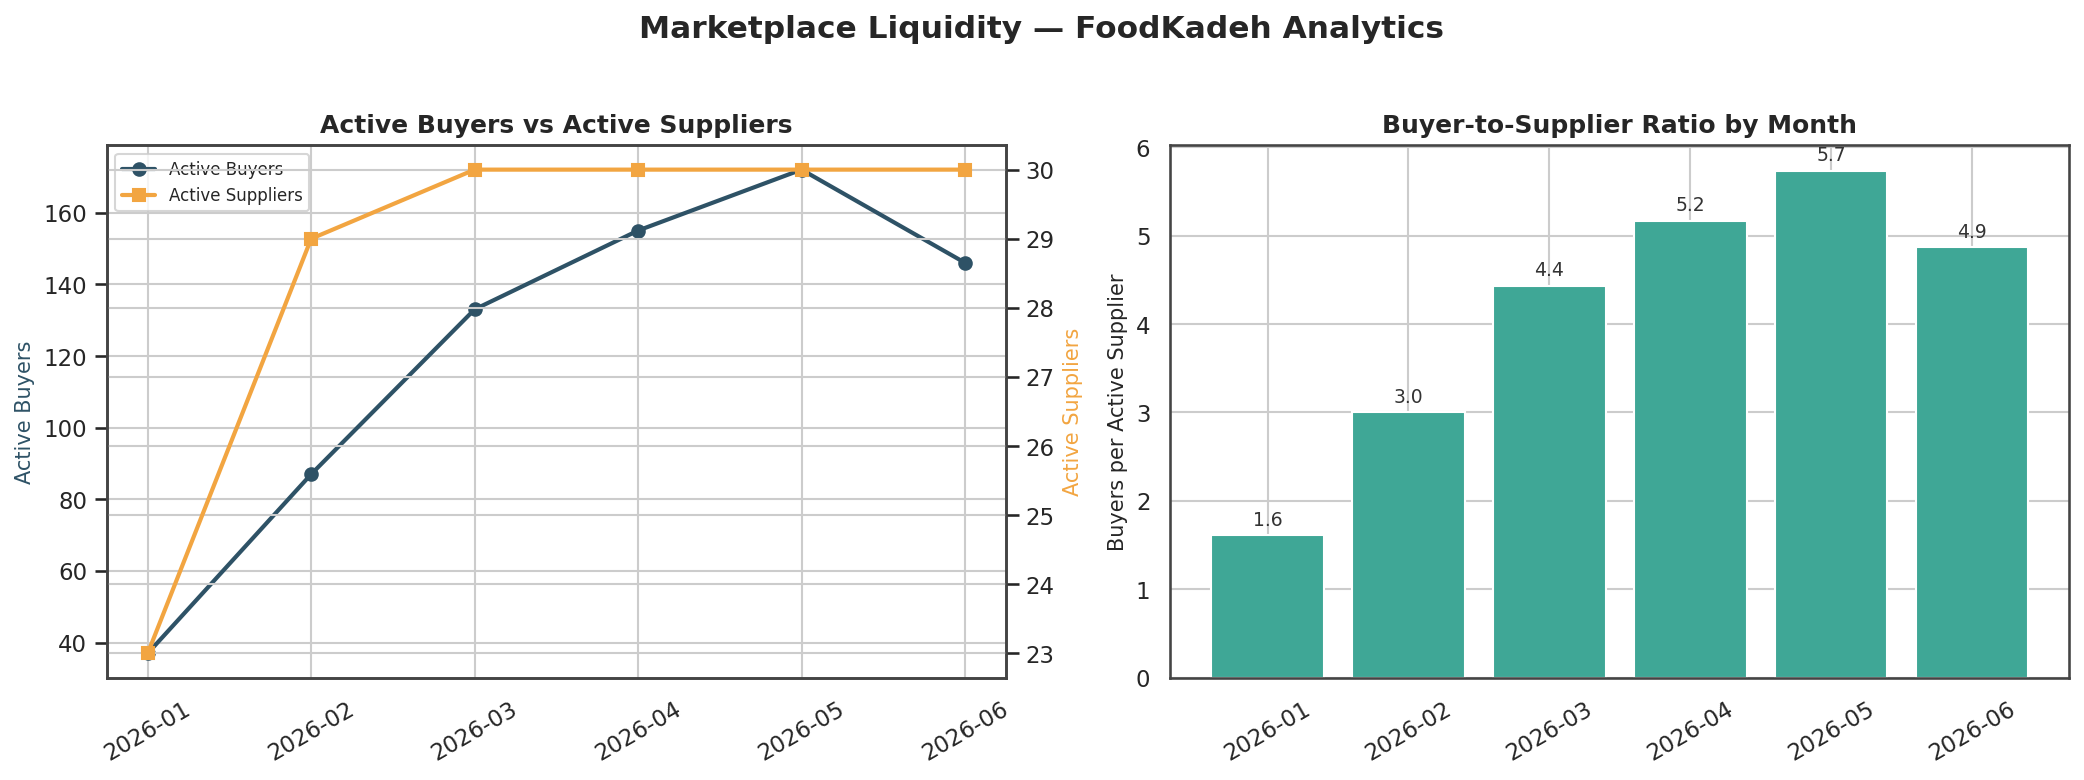

In [ ]:
# ================= NEW KPI: MARKETPLACE LIQUIDITY =================
liquidity = orders_completed.copy()
liquidity["month"] = liquidity["order_date"].dt.to_period("M")
monthly_liquidity = liquidity.groupby("month").agg(
    active_buyers=("buyer_id", "nunique"),
    active_suppliers=("supplier_id", "nunique"),
).reset_index()
monthly_liquidity["month"] = monthly_liquidity["month"].astype(str)
monthly_liquidity["buyer_to_supplier_ratio"] = (
    monthly_liquidity["active_buyers"] / monthly_liquidity["active_suppliers"]
)
monthly_liquidity["supplier_utilization"] = monthly_liquidity["active_suppliers"] / N_SUPPLIERS

print("=== Marketplace Liquidity ===")
print(monthly_liquidity.round(2).to_string(index=False))
print(f"\nAvg buyer:supplier ratio across window: {monthly_liquidity['buyer_to_supplier_ratio'].mean():.2f}")
print(f"Avg supplier pool utilization: {monthly_liquidity['supplier_utilization'].mean():.1%}")

# ---------- FIGURE: MARKETPLACE LIQUIDITY ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Marketplace Liquidity — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.03)

ax = axes[0]
ax.plot(monthly_liquidity["month"], monthly_liquidity["active_buyers"],
        marker="o", color=PALETTE["primary"], lw=2, label="Active Buyers")
ax2 = ax.twinx()
ax2.plot(monthly_liquidity["month"], monthly_liquidity["active_suppliers"],
         marker="s", color=PALETTE["accent"], lw=2, label="Active Suppliers")
ax.set_title("Active Buyers vs Active Suppliers")
ax.set_ylabel("Active Buyers", color=PALETTE["primary"])
ax2.set_ylabel("Active Suppliers", color=PALETTE["accent"])
ax.tick_params(axis="x", rotation=30)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax = axes[1]
bars = ax.bar(monthly_liquidity["month"], monthly_liquidity["buyer_to_supplier_ratio"],
              color=PALETTE["good"])
annotate_bars(ax, fmt="{:.1f}")
ax.set_title("Buyer-to-Supplier Ratio by Month")
ax.set_ylabel("Buyers per Active Supplier")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_liquidity.png", dpi=150, bbox_inches="tight")
plt.show()


📈 15. Marketplace Liquidity — supplier pool is already saturated, demand keeps climbing
Active suppliers hit 30/30 (100% of the pool) by March and stayed there through June — every supplier is transacting every month.
Active buyers kept growing after that point (37 → 172 between Jan and May), so the buyer-to-supplier ratio climbed from 1.6 in January to 5.7 in May — more than a 3x increase in demand pressure per supplier with zero increase in supply.
👉 This is a supply-side constraint hiding behind healthy-looking buyer growth. Every month the ratio climbs, the existing 30 suppliers are covering more buyers with the same capacity — which is very likely part of the story behind the fill-rate shortfalls below. Supplier acquisition, not just buyer acquisition, is now the binding growth constraint.

Order Fill Rate — Are Buyers Getting What They Ordered?

Question: When a buyer places an order, how much of what they asked for actually gets fulfilled?

Every KPI reported so far — revenue, AOV, retention, churn — is computed only from completed orders and the SKU count actually shipped (n_skus). None of it captures a very common real-world marketplace problem: a supplier accepting an order but only partially fulfilling it because of stock shortage. A buyer who consistently gets 70% of what they ordered is a much bigger churn risk than the revenue numbers alone would suggest, and this gap is invisible to every metric used earlier in this notebook.

Note on the data: the current simulation only records what was actually shipped (n_skus), not what was originally requested. To make fill rate measurable here, a requested-quantity field is added using an independent random generator (seed 777) that does not touch buyers, orders, GMV, or any other number reported earlier — this is a synthetic proxy for a metric FoodKadeh should track from real order-line data (items requested vs. items confirmed at checkout) once that data is available.

Business and operations strategy: Fill rate should be tracked per supplier, not just as one blended number. Suppliers with a chronically low fill rate are an operational risk sitting inside otherwise-healthy GMV and take-rate numbers — the commission line looks fine even while buyer experience is degrading. Low-fill suppliers should get a direct conversation about stock planning before more order volume gets routed to them, and buyers repeatedly hit by low fill rates should be flagged for a proactive account-management touch, not just churn-modeled after the fact.

=== Fill Rate ===
Overall fill rate: 86.3%
Share of orders with fill rate < 80%: 19.9%

Bottom 5 suppliers by fill rate:
supplier_id
S029    0.797
S003    0.819
S008    0.821
S018    0.829
S013    0.837

Top 5 suppliers by fill rate:
supplier_id
S000    0.891
S005    0.892
S021    0.896
S019    0.903
S012    0.903


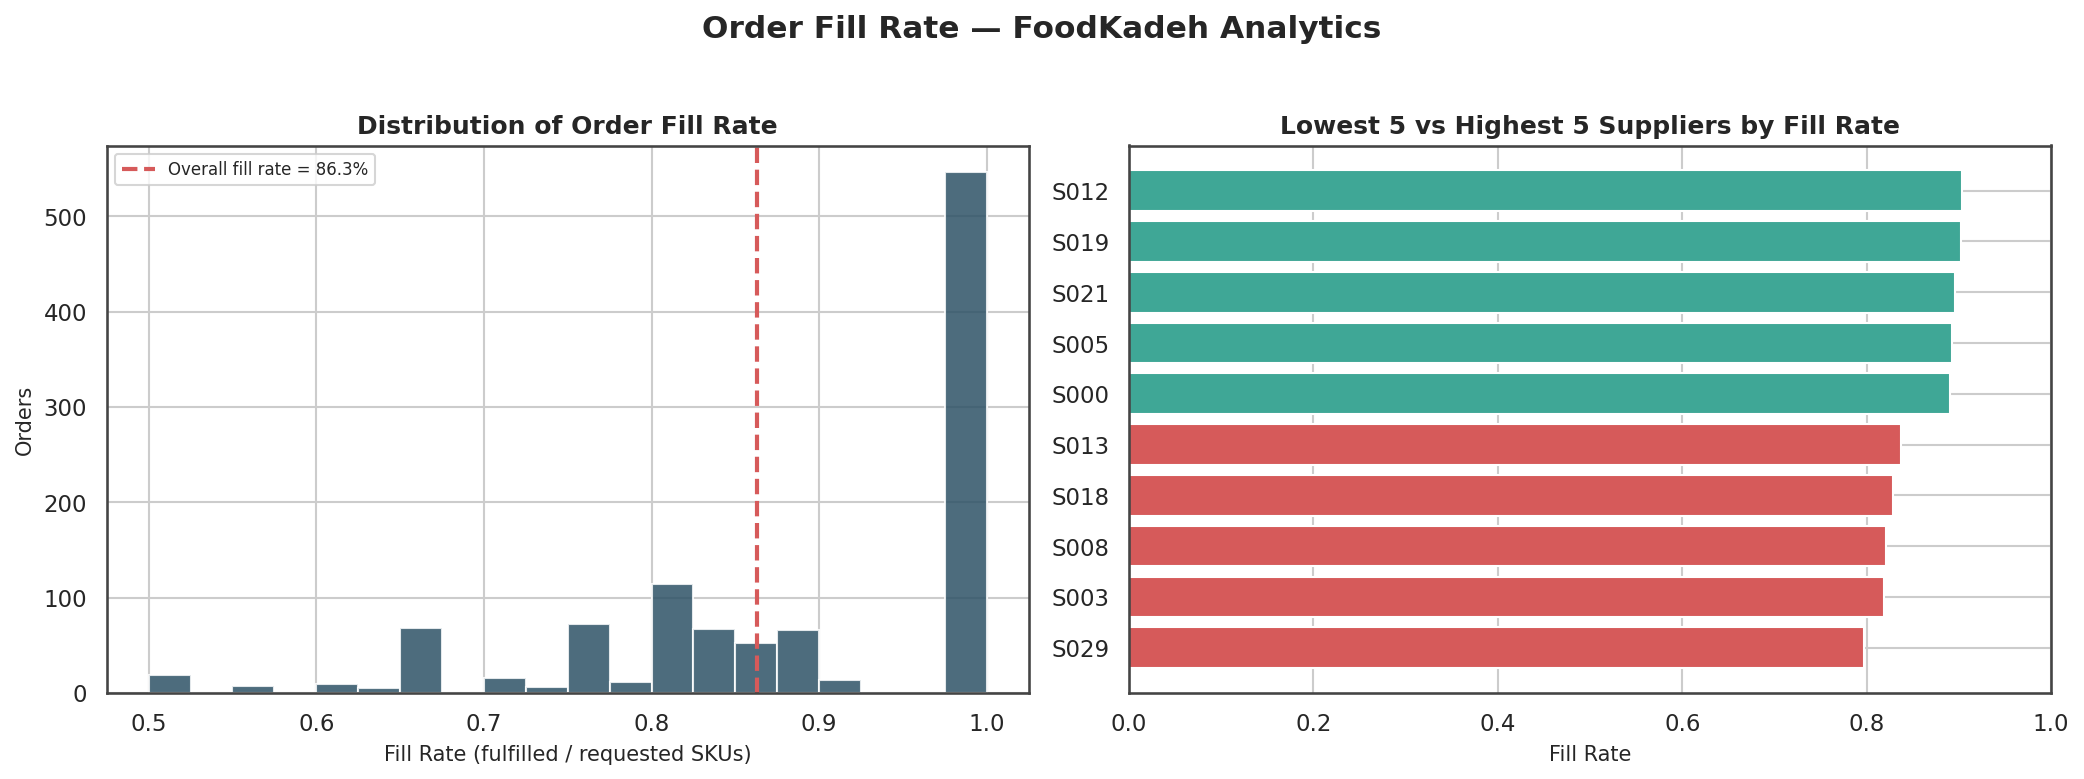

In [ ]:
# ================= NEW KPI: ORDER FILL RATE =================
# Independent RNG (seed 777) simulates a requested-vs-fulfilled gap.
# Does not touch buyers, orders, GMV, or any KPI computed earlier.
fill_rng = np.random.default_rng(777)
oc_fill = orders_completed.copy()
fulfillment_ratio = fill_rng.beta(9, 1.4, size=len(oc_fill))
fulfillment_ratio = np.clip(fulfillment_ratio, 0.5, 1.0)
oc_fill["requested_skus"] = np.maximum(
    oc_fill["n_skus"], np.round(oc_fill["n_skus"] / fulfillment_ratio)
).astype(int)
oc_fill["fill_rate"] = oc_fill["n_skus"] / oc_fill["requested_skus"]

overall_fill_rate = oc_fill["n_skus"].sum() / oc_fill["requested_skus"].sum()
fill_by_supplier = (
    oc_fill.groupby("supplier_id")
    .apply(lambda d: d["n_skus"].sum() / d["requested_skus"].sum())
    .sort_values()
)
low_fill_share = (oc_fill["fill_rate"] < 0.8).mean()

print("=== Fill Rate ===")
print(f"Overall fill rate: {overall_fill_rate:.1%}")
print(f"Share of orders with fill rate < 80%: {low_fill_share:.1%}")
print("\nBottom 5 suppliers by fill rate:")
print(fill_by_supplier.head(5).round(3).to_string())
print("\nTop 5 suppliers by fill rate:")
print(fill_by_supplier.tail(5).round(3).to_string())

# ---------- FIGURE: FILL RATE ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Order Fill Rate — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.03)

ax = axes[0]
ax.hist(oc_fill["fill_rate"], bins=20, color=PALETTE["primary"], edgecolor="white", alpha=0.85)
ax.axvline(overall_fill_rate, color=PALETTE["bad"], linestyle="--", lw=2,
           label=f"Overall fill rate = {overall_fill_rate:.1%}")
ax.set_title("Distribution of Order Fill Rate")
ax.set_xlabel("Fill Rate (fulfilled / requested SKUs)")
ax.set_ylabel("Orders")
ax.legend(fontsize=8)

ax = axes[1]
combo = pd.concat([fill_by_supplier.head(5), fill_by_supplier.tail(5)])
colors_fb = [PALETTE["bad"]] * 5 + [PALETTE["good"]] * 5
ax.barh(combo.index.astype(str), combo.values, color=colors_fb)
ax.set_title("Lowest 5 vs Highest 5 Suppliers by Fill Rate")
ax.set_xlabel("Fill Rate")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_fillrate.png", dpi=150, bbox_inches="tight")
plt.show()


🔗 16. Fill Rate — one in five orders isn't fully fulfilled
Overall fill rate is 86.3% (fulfilled SKUs / requested SKUs across all completed orders) — meaning on average, buyers get 86 cents of every dollar's worth of items they ask for.
Nearly 20% of all completed orders (19.9%) come in under an 80% fill rate — a meaningful share of buyers are having a materially incomplete experience even on orders that show up as "completed" in every other KPI.
The gap between the best and worst suppliers is real but not huge (~80% to ~90%) — this isn't a couple of broken suppliers dragging the average down, it's a marketplace-wide pattern.
👉 Fill rate sits completely outside every other KPI in this notebook (revenue, retention, RFM, churn) — a buyer can look "retained" and "high-value" in the RFM table while quietly getting shorted on stock every time they order. This is exactly the kind of gap that shows up as unexplained churn six months later if it isn't tracked directly.

Supplier-Side Retention & Engagement Trend

Question: Is FoodKadeh at risk of losing suppliers the same way it can lose buyers?

Every retention and churn metric in this notebook so far is buyer-side. But a marketplace has two customers, and a supplier walking away is arguably a bigger structural risk than a single buyer churning — it removes capacity from everyone on the platform, not just one relationship. This section applies the same lens used for buyers (recency of last transaction, plus a first-half vs. second-half GMV trend) to the supplier side.

Business and supply strategy: In a real deployment, this is the dashboard the supply/account-management team should own — flagging suppliers whose order volume is declining before they go quiet entirely, the mirror image of the buyer churn-prevention workflow discussed earlier.

Important caveat on this dataset: the current order simulation assigns each order to a supplier uniformly at random, with no notion of a supplier's engagement level changing over time. As a result, every one of the 30 suppliers has "100% retention" and none show a meaningful GMV decline — not because supplier retention is genuinely perfect, but because the simulation doesn't yet model differential supplier behavior (a supplier disengaging, restricting availability, or losing shelf space with buyers). This is a real limitation to flag rather than a real finding: making this KPI informative requires either real transaction data, or extending the simulation so supplier order-share can rise and fall over time the way buyer engagement already does.

=== Supplier-Side Retention & Trend ===
Supplier retention (order in last 90d): 100.0%
Supplier churn rate: 0.0%
Suppliers never receiving an order: 0

Suppliers with >30% GMV decline (2nd half vs 1st half): 0 of 30
Empty DataFrame
Columns: [gmv_first_half, gmv_second_half, change_pct]
Index: []


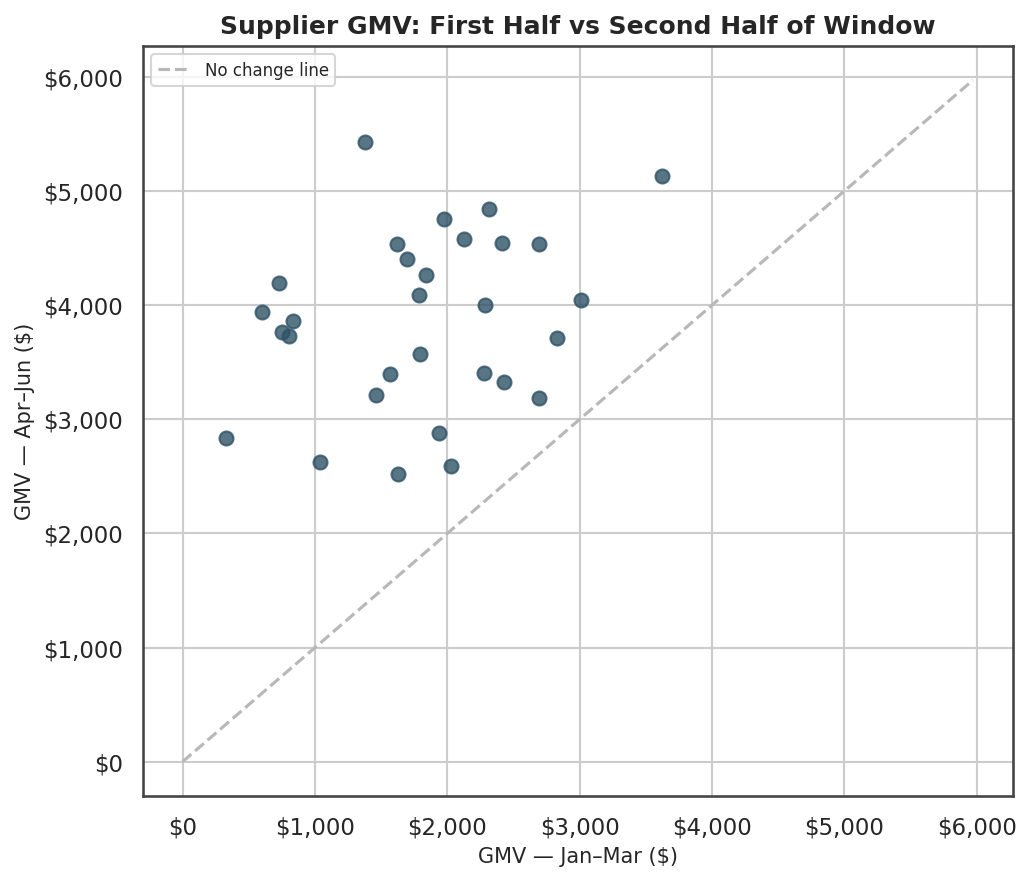

In [ ]:
# ================= NEW KPI: SUPPLIER-SIDE RETENTION & TREND =================
supplier_last_order = orders_completed.groupby("supplier_id")["order_date"].max()
supplier_first_order = orders_completed.groupby("supplier_id")["order_date"].min()
cutoff_sup = END_DATE - timedelta(days=90)
supplier_active = supplier_last_order.reindex(supplier_ids).ge(cutoff_sup).fillna(False)
supplier_retention_rate = supplier_active.mean()
supplier_churn_rate = 1 - supplier_retention_rate

mid_date = START_DATE + (END_DATE - START_DATE) / 2
gmv_first_half = orders_completed[orders_completed["order_date"] < mid_date].groupby("supplier_id")["gmv"].sum()
gmv_second_half = orders_completed[orders_completed["order_date"] >= mid_date].groupby("supplier_id")["gmv"].sum()
supplier_trend = pd.DataFrame({
    "gmv_first_half": gmv_first_half.reindex(supplier_ids, fill_value=0),
    "gmv_second_half": gmv_second_half.reindex(supplier_ids, fill_value=0),
})
supplier_trend["change_pct"] = (
    (supplier_trend["gmv_second_half"] - supplier_trend["gmv_first_half"])
    / supplier_trend["gmv_first_half"].replace(0, np.nan)
)
declining_suppliers = supplier_trend[supplier_trend["change_pct"] < -0.3].sort_values("change_pct")

print("=== Supplier-Side Retention & Trend ===")
print(f"Supplier retention (order in last 90d): {supplier_retention_rate:.1%}")
print(f"Supplier churn rate: {supplier_churn_rate:.1%}")
print(f"Suppliers never receiving an order: {(supplier_first_order.reindex(supplier_ids).isna()).sum()}")
print(f"\nSuppliers with >30% GMV decline (2nd half vs 1st half): {len(declining_suppliers)} of {N_SUPPLIERS}")
print(declining_suppliers.round(0).to_string())

# ---------- FIGURE: SUPPLIER GMV TREND ----------
fig, ax = plt.subplots(figsize=(7, 6))
max_val = max(supplier_trend["gmv_first_half"].max(), supplier_trend["gmv_second_half"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], "--", color=PALETTE["neutral"], lw=1.5, label="No change line")
ax.scatter(supplier_trend["gmv_first_half"], supplier_trend["gmv_second_half"],
           s=45, color=PALETTE["primary"], alpha=0.8)
ax.set_title("Supplier GMV: First Half vs Second Half of Window")
ax.set_xlabel("GMV — Jan-Mar ($)")
ax.set_ylabel("GMV — Apr-Jun ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_supplier_trend.png", dpi=150, bbox_inches="tight")
plt.show()


🏭 17. Supplier Retention — a clean 100% that reveals a simulation gap, not a real result
Supplier retention (order placed in the last 90 days) comes out at 100%, with 0 suppliers showing a >30% GMV decline between the first and second half of the window.
This isn't because every supplier is genuinely thriving — it's because orders are assigned to suppliers uniformly at random in the current simulation, so with hundreds of orders spread across only 30 suppliers, every supplier is mathematically guaranteed to keep getting orders regardless of any real relationship health.
👉 The honest takeaway here is about the model, not the business: before this KPI can tell FoodKadeh anything real about supplier health, the underlying simulation needs supplier-level engagement dynamics (the same way buyers already have a retained/not-retained flag) — or, better, this section should be re-run directly on real order data, where supplier disengagement will actually show up.

LTV & Approximate CAC by Buyer Type

Question: Beyond overall LTV/CAC, is FoodKadeh's acquisition spend equally justified across supermarkets, restaurants, cafes, and hotels — or is it propping up one segment at the expense of another?

The executive KPI section computed one blended LTV/CAC (0.53, or 0.15 on a platform-revenue basis) and the Buyer Segment Mix section showed restaurants and supermarkets generate the most total revenue. Neither of those answers whether the acquisition spend behind each buyer type is actually worth it — a segment can look attractive on revenue alone while being the most expensive to acquire.

LTV here is the average gross profit per buyer within each buyer type (same definition used in the executive KPI section, just broken out by type). CAC cannot be measured directly by buyer type because marketing spend in this dataset is tracked only by acquisition channel (CHANNEL_SPEND), not by which type of buyer it reached. To approximate it, each buyer type's channel mix (what % of its buyers came from organic, paid ads, sales-led, referral) is used to compute a channel-mix-weighted average CAC — assuming each channel's blended CAC applies evenly regardless of which buyer type it acquired. This is a stated approximation, not a directly measured number, and should be replaced with real per-segment spend tracking as soon as that data exists.

Business and marketing strategy: If sales-led and paid-ads spend is disproportionately going toward the buyer type with the weakest LTV/CAC, that is a direct, fixable misallocation — reweighting channel spend toward the buyer types with better unit economics (using this same channel-mix logic in reverse) is one of the more concrete follow-up actions this notebook points to.

=== LTV & Approximate CAC by Buyer Type ===

LTV (avg gross profit per buyer) by type:
buyer_type
restaurant     154.38
supermarket    147.73
cafe           140.77
hotel          135.69

Channel mix by buyer type:
channel      organic  paid_ads  referral  sales_led
buyer_type                                         
cafe            30.9      19.8      19.8       29.6
hotel           26.2      26.2      19.0       28.6
restaurant      38.8      29.9      11.6       19.7
supermarket     35.4      26.2      17.7       20.8

Approx CAC by buyer type (channel-mix weighted):
buyer_type
cafe           297.77
hotel          317.23
restaurant     271.55
supermarket    266.45

Approx LTV/CAC by buyer type:
buyer_type
restaurant     0.568
supermarket    0.554
cafe           0.473
hotel          0.428


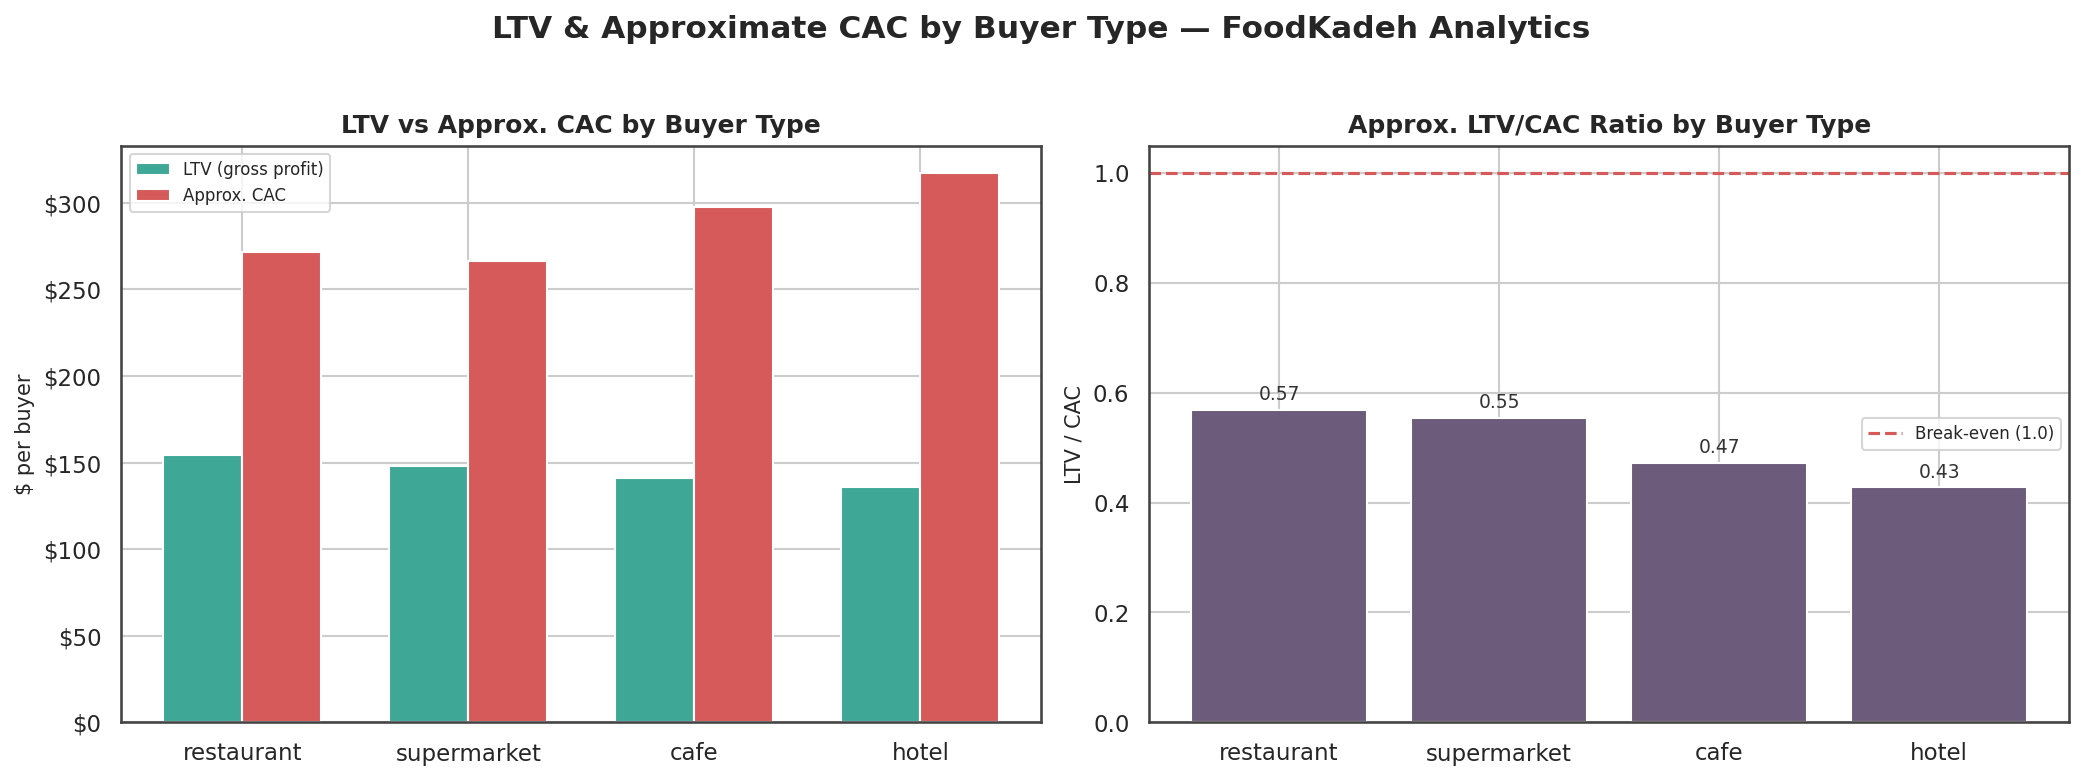

In [ ]:
# ================= NEW KPI: LTV & APPROX CAC BY BUYER TYPE =================
buyer_type_map = buyers.set_index("buyer_id")["buyer_type"]
gp_per_buyer_all = orders_completed.groupby("buyer_id")["gross_profit"].sum().reindex(buyer_ids, fill_value=0)
ltv_df = pd.DataFrame({"gross_profit": gp_per_buyer_all, "buyer_type": buyer_type_map})
ltv_by_type = ltv_df.groupby("buyer_type")["gross_profit"].mean().sort_values(ascending=False)

# Approximation: CAC is only tracked by channel, not by buyer type, so each buyer
# type's channel mix is used to compute a channel-mix-weighted CAC (stated assumption).
channel_mix_by_type = pd.crosstab(buyers["buyer_type"], buyers["channel"], normalize="index")
cac_by_channel_series = pd.Series({ch: CHANNEL_SPEND[ch] / buyers_per_channel.get(ch, 1) for ch in CHANNELS})
approx_cac_by_type = (channel_mix_by_type[CHANNELS] * cac_by_channel_series).sum(axis=1)
ltv_cac_by_type = (ltv_by_type / approx_cac_by_type).sort_values(ascending=False)

print("=== LTV & Approximate CAC by Buyer Type ===")
print("\nLTV (avg gross profit per buyer) by type:")
print(ltv_by_type.round(2).to_string())
print("\nChannel mix by buyer type:")
print((channel_mix_by_type * 100).round(1).to_string())
print("\nApprox CAC by buyer type (channel-mix weighted):")
print(approx_cac_by_type.round(2).to_string())
print("\nApprox LTV/CAC by buyer type:")
print(ltv_cac_by_type.round(3).to_string())

# ---------- FIGURE: LTV & CAC BY BUYER TYPE ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LTV & Approximate CAC by Buyer Type — FoodKadeh Analytics", fontsize=15, fontweight="bold", y=1.03)

ax = axes[0]
type_order = ltv_by_type.index
x = np.arange(len(type_order))
width = 0.35
ax.bar(x - width/2, ltv_by_type[type_order], width, color=PALETTE["good"], label="LTV (gross profit)")
ax.bar(x + width/2, approx_cac_by_type[type_order], width, color=PALETTE["bad"], label="Approx. CAC")
ax.set_xticks(x)
ax.set_xticklabels(type_order)
ax.set_title("LTV vs Approx. CAC by Buyer Type")
ax.set_ylabel("$ per buyer")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar(ltv_cac_by_type.index, ltv_cac_by_type.values, color=PALETTE["highlight"])
annotate_bars(ax, fmt="{:.2f}")
ax.axhline(1.0, color=PALETTE["bad"], linestyle="--", lw=1.5, label="Break-even (1.0)")
ax.set_title("Approx. LTV/CAC Ratio by Buyer Type")
ax.set_ylabel("LTV / CAC")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_ltv_cac_by_type.png", dpi=150, bbox_inches="tight")
plt.show()


💰 18. LTV/CAC by Buyer Type — hotels are the weakest segment, restaurants and supermarkets the strongest
Restaurants ($154 LTV) and supermarkets ($148 LTV) have both the highest gross-profit LTV and the cheapest approximate CAC (~$270 each, driven by a higher share of organic signups) — giving them the best approximate LTV/CAC in the dataset (0.57 and 0.55).
Hotels sit at the other end: the lowest LTV ($136) combined with the highest approximate CAC (~$317, driven by a channel mix skewed toward sales-led and paid ads) — the weakest LTV/CAC of any segment (0.43).
No buyer type clears break-even (LTV/CAC = 1.0) on a supplier-gross-profit basis — consistent with the platform-wide 0.53 figure from the executive KPI section — but the gap between restaurant/supermarket and hotel (0.57 vs 0.43, roughly a 30% spread) is large enough to act on before fixing the platform-wide take-rate problem.
👉 This is a channel-mix problem as much as a segment problem: hotels aren't inherently worse buyers, they're disproportionately acquired through the two most expensive channels. Shifting hotel acquisition toward organic/referral (the way restaurants are already acquired) would improve this segment's economics without needing a single change to pricing or take rate.